# Western Union directional corridor analysis

Self-contained local Jupyter workspace for the 53,130 directed market pairs. The embedded data pack is extracted into a local runtime folder and loaded into clearly named pandas DataFrames. Use `select_pair(origin, destination)` with WU two-letter market codes.

## Loaded tables

| DataFrame | Rows | Columns |
|---|---:|---:|
| `corridor_universe` | 53,130 | 30 |
| `corridor_products` | 52,022 | 24 |
| `rank_stability` | 8,572 | 17 |
| `top10` | 10 | 16 |
| `markets` | 301 | 5 |
| `graph_corridors` | 23,960 | 10 |
| `graph_channels` | 23,960 | 13 |
| `q12_q13_summary` | 10 | 16 |

**Coverage:** every pair has a `corridor_universe` row. Product, model, graph, and enrichment rows exist only where those layers have evidence. `null` means unavailable, not zero. The graph and Q12/Q13 tables are earlier or incomplete snapshots; use `corridor_universe`, `corridor_products`, and `top10` for the current Q10 view.

## Data-source roadmap

These are the full source families for extending the analysis. They are tracked here separately from the eight tables currently loaded in the runtime.

| # | Dataset | Raw granularity | Best uses |
|---:|---|---|---|
| 1 | **World Bank Remittance Prices Worldwide (RPW), 2011–2025 Q3** | Provider × corridor × quarter × product | Pricing, WU presence/share-of-observations, corridor coverage, digital vs cash, exclusivity proxies, competitive intensity |
| 2 | **World Bank/KNOMAD bilateral remittance matrix** | Origin × destination country | Estimate corridor sizes, top-10 corridors, concentration, weight RPW observations economically |
| 3 | **World Bank WDI remittance inflows/outflows API** | Country × year | Global market size, 10/20/30-year growth, country concentration, 2025 reconstruction |
| 4 | **Global Findex respondent-level microdata** | Individual respondent | Q9 unbanked/underbanked senders/receivers; account/mobile-money status; demographic cuts |
| 5 | **Banxico remittance micro/tables + CEMLA series** | Mexico remittances by channel/time/geography | Cash vs account deposit, digital migration, payout method, receiver behavior |
| 6 | **WU + competitor location-locator data** | Individual physical agent/location | Q13 location density, nearest-store distance, corridor-side network density |
| 7 | **Census/ACS + population rasters / WorldPop** | Tract/grid population | Population-weight WU accessibility rather than naive store density |
| 8 | **OpenStreetMap + OSRM routing data** | Road graph / route matrix | Actual travel distance to WU/Ria/MoneyGram/etc., not straight-line distance |
| 9 | **FINABIEN Mexico outlet roster JSON** | Individual locations | Mexico-side benchmark/competitor network and access calculations |
| 10 | **Regulator/MSB registries** | Licensed entity/location | Reconstruct agents and competitors where their own locator/API is incomplete |
| 11 | **UNCDF Nepal IME Pay dataset** | ~51m transactions + 993 surveys + interviews | Mobile-wallet receipt behavior, cash-out, retention/use of remittances |
| 12 | **UNCDF Bangladesh/BRAC remittance dataset** | ~4.2m transaction records + 507 surveys | Q11(b): what receivers actually do with digitally received remittances |
| 13 | **GSMA mobile-money datasets** | Country/provider/time transaction series | Q11(a), wallet penetration and international-remittance-to-wallet trends |
| 14 | **FinScope microdata** | Individual survey respondents | Remittance provider/channel choice; one Zambia wave identifies WU as a response |
| 15 | **Central-bank remittance datasets by country** | Month/channel/payment instrument | Fill World Bank gaps and build receiver-channel panels |
| 16 | **UN DESA International Migrant Stock** | Origin × destination × year | Fundamental corridor-volume model and migration elasticity |
| 17 | **Bilateral migration / diaspora matrices** | Country pair | Combine with bilateral remittance flows to estimate remittances per migrant |
| 18 | **Competitor filings/operating datasets** | Company × quarter/year | Transactions, principal, revenue, take rate, agent count; normalize WU vs Ria/Remitly/Intermex/MoneyGram |
| 19 | **Florida MSB registration downloads / other state registries** | Individual license/location | U.S. physical-location validation and network overlap |
| 20 | **EBA payment-institution register** | Institution × country/authorization | European competitor footprint, licensing, and potential corridor availability |


In [1]:
#@title Load the 20-source roadmap pack and inspect bilateral flows
import pathlib, zipfile
import pandas as pd
from IPython.display import display

SOURCE_ARCHIVE = pathlib.Path.cwd() / "WU_Roadmap_Source_Pack.zip"
if not SOURCE_ARCHIVE.exists():
    raise FileNotFoundError("Place WU_Roadmap_Source_Pack.zip beside this notebook, then rerun this cell.")
SOURCE_DIR = pathlib.Path.cwd() / "local_runtime" / "wu_roadmap_sources"
SOURCE_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(SOURCE_ARCHIVE) as zf:
    zf.extractall(SOURCE_DIR)

ROADMAP_DATA = {p.stem: pd.read_parquet(p) for p in sorted(SOURCE_DIR.glob("*.parquet"))}
globals().update(ROADMAP_DATA)
roadmap_loaded_tables = pd.DataFrame([
    {"DataFrame": name, "rows": len(frame), "columns": len(frame.columns)}
    for name, frame in ROADMAP_DATA.items()
]).sort_values("DataFrame", ignore_index=True)

print("ROADMAP AVAILABILITY")
status_order = pd.CategoricalDtype(["loaded", "partial", "reference", "missing"], ordered=True)
roadmap_status = source_manifest.copy()
roadmap_status["status"] = roadmap_status["status"].astype(status_order)
display(roadmap_status.sort_values(["status", "roadmap_item"]).style.format({"loaded_rows": "{:,}"}))
display(roadmap_status.groupby("status", observed=False).size().rename("roadmap_items").to_frame())

print("LOADED DATAFRAMES")
display(roadmap_loaded_tables)
print("Loaded", f"{sum(len(frame) for frame in ROADMAP_DATA.values()):,}", "records into", len(ROADMAP_DATA), "roadmap DataFrames")

print("BILATERAL REMITTANCE FLOWS USED IN CORRIDOR WEIGHTING")
bilateral_flows = bilateral_remittance_2024[[
    "y", "s", "r", "v", "source_country", "receive_country", "corridor", "neutral_rank", "source_url"
]].copy()
bilateral_flows["flow_usd"] = pd.to_numeric(bilateral_flows["v"], errors="coerce")
display(bilateral_flows.sort_values("flow_usd", ascending=False).head(20).style.format({"flow_usd": "USD {:,.0f}"}))
print("Directional corridors:", f"{len(bilateral_flows):,}")
print("Year(s):", sorted(bilateral_flows["y"].dropna().astype(str).unique()))
print("The flow column is the modeled bilateral remittance estimate. WU corridor shares are downstream model outputs, not disclosed company data.")

def roadmap_pair(origin_iso3="USA", destination_iso3="MEX"):
    return bilateral_flows.loc[
        bilateral_flows["s"].eq(origin_iso3.upper()) & bilateral_flows["r"].eq(destination_iso3.upper())
    ].copy()

US_MEX_BILATERAL = roadmap_pair("USA", "MEX")

ROADMAP AVAILABILITY


,roadmap_item,source_family,status,loaded_dataframes,loaded_rows,summed_columns,coverage_note
0,1,"World Bank RPW, 2011–2025 Q3",loaded,rpw_history,"253,960",49,Full observation-level workbook converted to Parquet; raw cell values retained as strings.
1,2,World Bank/KNOMAD bilateral remittance matrix,loaded,bilateral_remittance_2024,"8,572",15,"8,572 directional 2024 modeled remittance flows. Columns prefixed modeled_wu_* are downstream WU allocation outputs, not disclosed corridor revenue."
3,4,Global Findex respondent microdata,loaded,findex_microdata,"144,090",199,"144,090 respondent rows and 199 variables; survey weights retained."
8,9,FINABIEN Mexico outlet roster,loaded,finabien_roster,"1,644",17,"1,644 outlet records with coordinates and address fields."
9,10,Regulator/MSB registries,loaded,"regulatory_agent_records, regulatory_agent_relationships, regulatory_outlet_relationships, regulatory_source_register","73,249",74,Seven-jurisdiction normalized registry evidence and relationship tables.
18,19,Florida MSB downloads / state registries,loaded,florida_msb_records,"42,656",35,Florida records are also included in the broader regulatory tables.
2,3,World Bank WDI remittance inflows/outflows,partial,wdi_remittances_wld_lmy,132,11,Received-remittance history for WLD and LMY only; full country inflow/outflow panel is not in the local corpus.
4,5,Banxico remittance tables + CEMLA,partial,"mexico_remittance_summary, source_documents",6,17,Structured Mexico summary plus frozen Banxico source documents; no CEMLA microdata table.
5,6,WU + competitor location-locator data,partial,"wu_locations_global, regulatory_agent_records","507,068",67,Full collected WU location table plus registry-derived agent records; competitor locator coverage is uneven.
6,7,Census/ACS + population rasters / WorldPop,partial,"miami_acs_demand_tracts, yucatan_population","3,333",298,Miami ACS tracts and Yucatán INEGI population points; no global WorldPop raster.


,roadmap_items
status,
loaded,6
partial,8
reference,1
missing,5


LOADED DATAFRAMES


,DataFrame,rows,columns
0,bangladesh_wallet_monthly,14,12
1,bilateral_remittance_2024,8572,15
2,colombia_remittances_monthly,31,21
3,finabien_roster,1644,17
4,findex_microdata,144090,199
5,florida_msb_records,42656,35
6,india_rbi_country_panel,9,6
7,mexico_remittance_summary,3,13
8,miami_access_distribution,27,16
9,miami_acs_demand_tracts,642,12


Loaded 963,977 records into 22 roadmap DataFrames
BILATERAL REMITTANCE FLOWS USED IN CORRIDOR WEIGHTING


,y,s,r,v,source_country,receive_country,corridor,neutral_rank,source_url,flow_usd
0,2024,USA,MEX,65855005077,United States of America,Mexico,United States of America -> Mexico,1.000000,https://www.sec.gov/Archives/edgar/data/1365135/000119312526061340/wu-20251231.htm; https://center-for-global-development.github.io/Bilateral-remittances-matrix-update/4-remittances-map.html; https://blogs.worldbank.org/en/peoplemove/bilateral-remittance-matrix-new,"USD 65,855,005,077"
1,2024,USA,IND,27250393272,United States of America,India,United States of America -> India,2.000000,https://www.sec.gov/Archives/edgar/data/1365135/000119312526061340/wu-20251231.htm; https://center-for-global-development.github.io/Bilateral-remittances-matrix-update/4-remittances-map.html; https://blogs.worldbank.org/en/peoplemove/bilateral-remittance-matrix-new,"USD 27,250,393,272"
4,2024,ARE,IND,26334542340,United Arab Emirates,India,United Arab Emirates -> India,5.000000,https://www.sec.gov/Archives/edgar/data/1365135/000119312526061340/wu-20251231.htm; https://center-for-global-development.github.io/Bilateral-remittances-matrix-update/4-remittances-map.html; https://blogs.worldbank.org/en/peoplemove/bilateral-remittance-matrix-new,"USD 26,334,542,340"
2,2024,USA,GTM,19680528363,United States of America,Guatemala,United States of America -> Guatemala,3.000000,https://www.sec.gov/Archives/edgar/data/1365135/000119312526061340/wu-20251231.htm; https://center-for-global-development.github.io/Bilateral-remittances-matrix-update/4-remittances-map.html; https://blogs.worldbank.org/en/peoplemove/bilateral-remittance-matrix-new,"USD 19,680,528,363"
6,2024,SAU,IND,15216172432,Saudi Arabia,India,Saudi Arabia -> India,7.000000,https://www.sec.gov/Archives/edgar/data/1365135/000119312526061340/wu-20251231.htm; https://center-for-global-development.github.io/Bilateral-remittances-matrix-update/4-remittances-map.html; https://blogs.worldbank.org/en/peoplemove/bilateral-remittance-matrix-new,"USD 15,216,172,432"
3,2024,USA,PHL,14216968526,United States of America,Philippines,United States of America -> Philippines,4.000000,https://www.sec.gov/Archives/edgar/data/1365135/000119312526061340/wu-20251231.htm; https://center-for-global-development.github.io/Bilateral-remittances-matrix-update/4-remittances-map.html; https://blogs.worldbank.org/en/peoplemove/bilateral-remittance-matrix-new,"USD 14,216,968,526"
17,2024,SAU,PAK,10565730481,Saudi Arabia,Pakistan,Saudi Arabia -> Pakistan,18.000000,https://www.sec.gov/Archives/edgar/data/1365135/000119312526061340/wu-20251231.htm; https://center-for-global-development.github.io/Bilateral-remittances-matrix-update/4-remittances-map.html; https://blogs.worldbank.org/en/peoplemove/bilateral-remittance-matrix-new,"USD 10,565,730,481"
9,2024,GBR,IND,10443491625,United Kingdom,India,United Kingdom -> India,10.000000,https://www.sec.gov/Archives/edgar/data/1365135/000119312526061340/wu-20251231.htm; https://center-for-global-development.github.io/Bilateral-remittances-matrix-update/4-remittances-map.html; https://blogs.worldbank.org/en/peoplemove/bilateral-remittance-matrix-new,"USD 10,443,491,625"
18,2024,KWT,IND,9506522122,Kuwait,India,Kuwait -> India,19.000000,https://www.sec.gov/Archives/edgar/data/1365135/000119312526061340/wu-20251231.htm; https://center-for-global-development.github.io/Bilateral-remittances-matrix-update/4-remittances-map.html; https://blogs.worldbank.org/en/peoplemove/bilateral-remittance-matrix-new,"USD 9,506,522,122"
19,2024,SAU,EGY,9308422513,Saudi Arabia,Egypt,Saudi Arabia -> Egypt,20.000000,https://www.sec.gov/Archives/edgar/data/1365135/000119312526061340/wu-20251231.htm; https://center-for-global-development.github.io/Bilateral-remittances-matrix-update/4-remittances-map.html; https://blogs.worldbank.org/en/peoplemove/bilateral-remittance-matrix-new,"USD 9,308,422,513"


Directional corridors: 8,572
Year(s): ['2024']
The flow column is the modeled bilateral remittance estimate. WU corridor shares are downstream model outputs, not disclosed company data.


In [2]:
#@title DataFrame catalog and 100-row sample browser
import pandas as pd
from IPython.display import display, clear_output
import ipywidgets as widgets

# Status describes coverage of the intended source family. Every local Parquet table is loaded in full.
meta = [
("bangladesh_wallet_monthly","12","One month of mobile-financial-services inward remittance activity","Bangladesh","2024-01 to 2025-02","Bangladesh Bank MFS and wage-remittance series","partial source family","Wallet receipt adoption and cash-out context"),
("bilateral_remittance_2024","2","One modeled sending-country to receiving-country remittance flow","Global; 8,572 directional country pairs","2024","World Bank / CGD bilateral remittances matrix update","fully loaded","Core: corridor size, rank, concentration, and economic weighting"),
("colombia_remittances_monthly","15","One month of national inward remittance value and underwriting fields","Colombia","2024-01 to 2026-07","Banco de la Republica series 15363","partial source family","Receiver-market trend and payment-rail context"),
("finabien_roster","9","One FINABIEN branch or outlet","Mexico; all 32 states","Roster retrieved 2026","Gobierno de Mexico / FINABIEN outlet roster","fully loaded","High: Mexico payout-network benchmark and access"),
("findex_microdata","4","One survey respondent with weight and financial-behavior variables","140 economies; 7 World Bank regions","2024","World Bank Global Findex respondent microdata","fully loaded","High: banked status, mobile money, digital payments, and remittance behavior"),
("florida_msb_records","19; also 10","One Florida principal-agent-location registry record","Florida, including limited out-of-state addresses","As of 2026-09-04","Florida Office of Financial Regulation MSB downloads","fully loaded; overlaps regulatory_agent_records","High: outlet validation and WU/competitor overlap"),
("india_rbi_country_panel","15","One sending-country share of remittances received by India","India; 8 named origins plus Other","FY2017, FY2021, FY2024","Reserve Bank of India survey extract","partial source family","India corridor calibration and origin mix"),
("mexico_remittance_summary","5; also 15","One annual Mexico total or one 2024 channel summary","Mexico","2023-2024","Banco de Mexico December 2024 release / CE80","partial source family","High for US-MX: flows, transactions, ticket, and payout channel"),
("miami_access_distribution","8","One provider x birth-country x routing-threshold access result","Miami-Dade; Mexico, Guatemala, Honduras-born populations","Derived 2026","ACS demand, provider locations, OpenStreetMap, OSRM","partial geographic extract","High for Miami case study: travel time and provider coverage"),
("miami_acs_demand_tracts","7","One tract with foreign-born demand counts and centroid","Miami-Dade County; 642 census tracts","ACS vintage not encoded","U.S. Census Bureau ACS B05006 extract","partial geographic extract","High for Miami case study: population-weighted access"),
("provider_benchmarks","18","One provider-period operating benchmark","Euronet group; Ria/Xe/Dandelion","FY2025","Euronet FY2025 public filing extract","partial source family","Competitor principal, transaction, ticket, and revenue normalization"),
("regulatory_agent_records","10","One normalized principal-agent-address registry record","Arkansas, Massachusetts, Florida, Jamaica, New Mexico, Dominican Republic","2025-12-31 to 2026-09-04","Official regulator and MSB registry downloads","fully loaded for collected jurisdictions","High: reconstruct agents and identify competing principals"),
("regulatory_agent_relationships","10","One legal-agent match linking WU with peer principal families","Arkansas, Florida, Jamaica, Massachusetts, New Mexico","2025-12-31 to 2026-09-04","Derived from official registry records","fully loaded for collected jurisdictions","High: agent multi-homing and exclusivity evidence"),
("regulatory_outlet_relationships","10","One outlet-address match linking WU with peer principal families","Arkansas, Florida, Jamaica, Massachusetts, New Mexico","2025-12-31 to 2026-09-04","Derived from official registry records","fully loaded for collected jurisdictions","High: same-location competition and network overlap"),
("regulatory_source_register","10","One acquired source file with URL, date, hash, and parse status","7 jurisdictions, including India source files","2025-12-31 to 2026-09-04","Official regulator/MSB source ledger","fully loaded","Audit: provenance and coverage boundaries"),
("rpw_history","1","One provider-product quote observation for a corridor and quarter","49 sending and 111 receiving economies; 382 observed corridor codes","2011 Q1 to 2025 Q3","World Bank Remittance Prices Worldwide workbook","fully loaded","Core: pricing, WU observation presence, channel mix, and competition"),
("source_documents","5, 13, 18","One document family retained as a local source reference","Mexico, global mobile money, and public-company coverage","2012-2026; varies","Banxico, GSMA, and public-company filings/releases","reference only","Audit/supporting: evidence not normalized as row-level data"),
("source_manifest","Control","One roadmap source family and its availability/limitation status","All 20 roadmap items","Current pack build","Generated from local source-pack inventory","fully loaded control table","Audit: identifies loaded, partial, reference, and missing sources"),
("wdi_remittances_wld_lmy","3","One aggregate-geography/year remittance-received observation","World and low/middle-income aggregate only","1960-2025","World Bank WDI API: BX.TRF.PWKR.CD.DT","partial source family","Long-run market growth; not usable for country ranking"),
("wu_locations_global","6","One WU location ID with market, address, coordinates, and service flags when available","211 WU market codes / 198 mapped ISO3 economies","Retrieved 2026-09-07","Western Union locations sitemap and locator collection","partial source family; WU table loaded","Core network footprint; detail/service coverage varies by location"),
("yucatan_population","7","One INEGI locality or municipality aggregate with demographic/housing fields","Yucatan; 106 municipalities plus aggregates","2020 census","INEGI 2020 locality census extract","partial geographic extract","High for Yucatan: population-weighted access and receiver density"),
("yucatan_routes","8","One locality-to-selected-site OSRM route result","Yucatan, Mexico","Derived 2026 from 2020 population and collected outlets","INEGI localities, WU/FINABIEN sites, OpenStreetMap, OSRM","partial geographic extract","High for Yucatan: travel time and distance to payout sites")]
cols=["dataframe","roadmap_item","row_represents","geographic_coverage","year_or_period","source","coverage_status","western_union_use"]
DATAFRAME_CATALOG=pd.DataFrame(meta,columns=cols)
DATAFRAME_CATALOG["rows"]=DATAFRAME_CATALOG.dataframe.map(lambda n:len(ROADMAP_DATA[n]))
DATAFRAME_CATALOG["columns"]=DATAFRAME_CATALOG.dataframe.map(lambda n:len(ROADMAP_DATA[n].columns))
total=int(DATAFRAME_CATALOG.rows.sum())
DATAFRAME_CATALOG["volume_share"]=DATAFRAME_CATALOG.rows/total
DATAFRAME_CATALOG["sample_rows"]=DATAFRAME_CATALOG.rows.clip(upper=100)
DATAFRAME_CATALOG=DATAFRAME_CATALOG[["dataframe","rows","volume_share","sample_rows","columns","roadmap_item","row_represents","geographic_coverage","year_or_period","source","coverage_status","western_union_use"]].sort_values("rows",ascending=False,ignore_index=True)
display(DATAFRAME_CATALOG.style.format({"rows":"{:,}","volume_share":"{:.2%}","sample_rows":"{:,}"}))
print(f"Catalog reconciles {total:,} rows across {len(DATAFRAME_CATALOG)} DataFrames.")
print("The raw total includes the Florida subset also present in regulatory_agent_records, plus control/reference rows.")
ROADMAP_SAMPLES={n:ROADMAP_DATA[n].head(100).copy() for n in DATAFRAME_CATALOG.dataframe}
print(f"Stored {sum(map(len,ROADMAP_SAMPLES.values())):,} sample rows in ROADMAP_SAMPLES.")
picker=widgets.Dropdown(options=DATAFRAME_CATALOG.dataframe.tolist(),value="bilateral_remittance_2024",description="DataFrame:",layout=widgets.Layout(width="650px"))
out=widgets.Output()
def show_sample(change=None):
 n=picker.value; m=DATAFRAME_CATALOG.set_index("dataframe").loc[n]
 with out:
  clear_output(wait=True)
  print(f"{n}: {int(m['rows']):,} total rows; showing {len(ROADMAP_SAMPLES[n]):,}")
  print(f"One row: {m['row_represents']}")
  print(f"Coverage: {m['geographic_coverage']} | Period: {m['year_or_period']} | Status: {m['coverage_status']}")
  print(f"WU use: {m['western_union_use']}")
  display(ROADMAP_SAMPLES[n])
picker.observe(show_sample,names="value")
display(picker,out); show_sample()


,dataframe,rows,volume_share,sample_rows,columns,roadmap_item,row_represents,geographic_coverage,year_or_period,source,coverage_status,western_union_use
0,wu_locations_global,"435,535",45.18%,100,32,6,"One WU location ID with market, address, coordinates, and service flags when available",211 WU market codes / 198 mapped ISO3 economies,Retrieved 2026-09-07,Western Union locations sitemap and locator collection,partial source family; WU table loaded,Core network footprint; detail/service coverage varies by location
1,rpw_history,"253,960",26.35%,100,49,1,One provider-product quote observation for a corridor and quarter,49 sending and 111 receiving economies; 382 observed corridor codes,2011 Q1 to 2025 Q3,World Bank Remittance Prices Worldwide workbook,fully loaded,"Core: pricing, WU observation presence, channel mix, and competition"
2,findex_microdata,"144,090",14.95%,100,199,4,One survey respondent with weight and financial-behavior variables,140 economies; 7 World Bank regions,2024,World Bank Global Findex respondent microdata,fully loaded,"High: banked status, mobile money, digital payments, and remittance behavior"
3,regulatory_agent_records,"71,533",7.42%,100,35,10,One normalized principal-agent-address registry record,"Arkansas, Massachusetts, Florida, Jamaica, New Mexico, Dominican Republic",2025-12-31 to 2026-09-04,Official regulator and MSB registry downloads,fully loaded for collected jurisdictions,High: reconstruct agents and identify competing principals
4,florida_msb_records,"42,656",4.43%,100,35,19; also 10,One Florida principal-agent-location registry record,"Florida, including limited out-of-state addresses",As of 2026-09-04,Florida Office of Financial Regulation MSB downloads,fully loaded; overlaps regulatory_agent_records,High: outlet validation and WU/competitor overlap
5,bilateral_remittance_2024,"8,572",0.89%,100,15,2,One modeled sending-country to receiving-country remittance flow,"Global; 8,572 directional country pairs",2024,World Bank / CGD bilateral remittances matrix update,fully loaded,"Core: corridor size, rank, concentration, and economic weighting"
6,yucatan_population,"2,691",0.28%,100,286,7,One INEGI locality or municipality aggregate with demographic/housing fields,Yucatan; 106 municipalities plus aggregates,2020 census,INEGI 2020 locality census extract,partial geographic extract,High for Yucatan: population-weighted access and receiver density
7,finabien_roster,"1,644",0.17%,100,17,9,One FINABIEN branch or outlet,Mexico; all 32 states,Roster retrieved 2026,Gobierno de Mexico / FINABIEN outlet roster,fully loaded,High: Mexico payout-network benchmark and access
8,regulatory_outlet_relationships,"1,121",0.12%,100,13,10,One outlet-address match linking WU with peer principal families,"Arkansas, Florida, Jamaica, Massachusetts, New Mexico",2025-12-31 to 2026-09-04,Derived from official registry records,fully loaded for collected jurisdictions,High: same-location competition and network overlap
9,yucatan_routes,698,0.07%,100,15,8,One locality-to-selected-site OSRM route result,"Yucatan, Mexico",Derived 2026 from 2020 population and collected outlets,"INEGI localities, WU/FINABIEN sites, OpenStreetMap, OSRM",partial geographic extract,High for Yucatan: travel time and distance to payout sites


Catalog reconciles 963,977 rows across 22 DataFrames.
The raw total includes the Florida subset also present in regulatory_agent_records, plus control/reference rows.
Stored 1,430 sample rows in ROADMAP_SAMPLES.


Dropdown(description='DataFrame:', index=5, layout=Layout(width='650px'), options=('wu_locations_global', 'rpw…

Output()

In [3]:
#@title 1. Load the local data pack (run first)
import json, pathlib, zipfile
import pandas as pd
from IPython.display import display

ARCHIVE = pathlib.Path.cwd() / "WU_Corridor_Analysis_Data.zip"
if not ARCHIVE.exists():
    raise FileNotFoundError("Place WU_Corridor_Analysis_Data.zip beside this notebook, then rerun this cell.")
DATA_DIR = pathlib.Path.cwd() / "local_runtime" / "wu_corridor_data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(ARCHIVE) as zf:
    zf.extractall(DATA_DIR)

DATA = {p.stem: pd.read_parquet(p) for p in sorted(DATA_DIR.glob("*.parquet"))}
globals().update(DATA)
with open(DATA_DIR / "US_MX_raw_quote.json", encoding="utf-8") as handle:
    US_MX_raw_quote = json.load(handle)
with open(DATA_DIR / "US_MX_pair_dossier.json", encoding="utf-8") as handle:
    US_MX_pair_dossier = json.load(handle)

loaded_tables = pd.DataFrame([
    {"DataFrame": name, "rows": len(frame), "columns": len(frame.columns)}
    for name, frame in DATA.items()
]).sort_values("DataFrame", ignore_index=True)
display(loaded_tables)
print("Loaded", f"{sum(len(frame) for frame in DATA.values()):,}", "tabular records into", len(DATA), "DataFrames")


,DataFrame,rows,columns
0,corridor_products,52022,24
1,corridor_universe,53130,30
2,graph_channels,23960,13
3,graph_corridors,23960,10
4,markets,301,5
5,q12_q13_summary,10,16
6,rank_stability,8572,17
7,top10,10,16


Loaded 161,965 tabular records into 8 DataFrames


In [4]:
#@title 2. Pair selector and reusable helpers
def _pair_rows(frame, origin, destination):
    origin, destination = origin.upper(), destination.upper()
    corridor_id = f"{origin}->{destination}"
    if {"origin_wu_code", "destination_wu_code"}.issubset(frame.columns):
        return frame.loc[(frame.origin_wu_code == origin) & (frame.destination_wu_code == destination)].copy()
    if "corridor_id" in frame.columns:
        return frame.loc[frame.corridor_id == corridor_id].copy()
    if "corridor" in frame.columns:
        return frame.loc[frame.corridor == corridor_id].copy()
    if "market_id" in frame.columns:
        return frame.loc[frame.market_id.isin([origin, destination])].copy()
    return frame.iloc[0:0].copy()

def select_pair(origin="US", destination="MX"):
    """Return every matching record, organized by dataset, for one directed pair."""
    result = {name: _pair_rows(frame, origin, destination) for name, frame in DATA.items()}
    result["record_counts"] = pd.DataFrame([
        {"dataset": name, "records": len(frame), "fields": len(frame.columns)}
        for name, frame in result.items()
    ])
    return result

def show_pair(pair):
    display(pair["record_counts"])
    for name, frame in pair.items():
        if name != "record_counts" and len(frame):
            print(f"\n{name}: {len(frame)} record(s)")
            display(frame)


In [5]:
#@title 3. Worked example: United States → Mexico
PAIR = select_pair("US", "MX")
show_pair(PAIR)

# Convenient aliases for analysis
PAIR_UNIVERSE = PAIR["corridor_universe"]
PAIR_PRODUCTS = PAIR["corridor_products"]
PAIR_STABILITY = PAIR["rank_stability"]
PAIR_TOP10 = PAIR["top10"]


,dataset,records,fields
0,corridor_products,3,24
1,corridor_universe,1,30
2,graph_channels,1,13
3,graph_corridors,1,10
4,markets,2,5
5,q12_q13_summary,1,16
6,rank_stability,1,17
7,top10,1,16



corridor_products: 3 record(s)


,corridor_id,origin_wu_code,destination_wu_code,send_currency,payout_currency,product_row_id,service_id,service_name,fund_out,fund_out_mnemonic,...,wallet_payout,funding_methods,payout_methods,speed,request_hash,response_hash,payload_fingerprint,timestamp,http_status,raw_evidence_path
49378,US->MX,US,MX,USD,MXN,2ba6d69e14b824ca5249e42b04d64e6a9ebb2783930bb8...,000,Money In Minutes,000,MM,...,None,"[""AC"",""AD"",""AP"",""AR"",""CA"",""CC"",""DC"",""GP""]","[""000"",""MM""]",0|0-4,2ba6d69e14b824ca5249e42b04d64e6a9ebb2783930bb8...,700b8a5ba131c024f385dc5b081b03933eb15e20fd080b...,df47f4ea8360150aaaeb6c2ff79aea2320fababd726f73...,2026-09-07T13:18:52+00:00,NaN,raw\quotes\2ba6d69e14b824ca5249e42b04d64e6a9eb...
49379,US->MX,US,MX,USD,MXN,2ba6d69e14b824ca5249e42b04d64e6a9ebb2783930bb8...,500,Direct to Bank,500,DB,...,None,"[""AC"",""AD"",""AP"",""AR"",""CA"",""CC"",""DC"",""GP""]","[""500"",""DB""]",0|0-1|0-4,2ba6d69e14b824ca5249e42b04d64e6a9ebb2783930bb8...,700b8a5ba131c024f385dc5b081b03933eb15e20fd080b...,df47f4ea8360150aaaeb6c2ff79aea2320fababd726f73...,2026-09-07T13:18:52+00:00,NaN,raw\quotes\2ba6d69e14b824ca5249e42b04d64e6a9eb...
49380,US->MX,US,MX,USD,MXN,2ba6d69e14b824ca5249e42b04d64e6a9ebb2783930bb8...,800,Mobile Money Transfer,800,MB,...,True,"[""AC"",""AD"",""AP"",""AR"",""CC"",""DC"",""GP""]","[""800"",""MB""]",0|0-4,2ba6d69e14b824ca5249e42b04d64e6a9ebb2783930bb8...,700b8a5ba131c024f385dc5b081b03933eb15e20fd080b...,df47f4ea8360150aaaeb6c2ff79aea2320fababd726f73...,2026-09-07T13:18:52+00:00,NaN,raw\quotes\2ba6d69e14b824ca5249e42b04d64e6a9eb...



corridor_universe: 1 record(s)


,corridor_id,origin_wu_code,destination_wu_code,origin_name,destination_name,origin_iso2_secondary,destination_iso2_secondary,origin_iso3_secondary,destination_iso3_secondary,origin_mapping_status,...,payout_currencies,request_hashes,response_hashes,latest_timestamp,digital,retail,cash_pickup,bank_payout,wallet_payout,channel_evidence_basis
48666,US->MX,US,MX,United States,Mexico,US,MX,USA,MEX,direct_code,...,"[""MXN""]","[""2ba6d69e14b824ca5249e42b04d64e6a9ebb2783930b...","[""700b8a5ba131c024f385dc5b081b03933eb15e20fd08...",2026-09-07T13:18:52+00:00,true,true,true,true,true,pair_product_response


...

,corridor,modeled_revenue_share,send_wu_sites,receive_wu_sites,send_confirmed_multibrand_pct,receive_confirmed_multibrand_pct,send_wu_p50_miles,send_wu_p90_miles,receive_wu_p50_miles,receive_wu_p90_miles,send_moneygram_p50_miles,send_ria_p50_miles,receive_moneygram_p50_miles,receive_ria_p50_miles,wu_relative_access_advantage,service_exclusivity_evidence_quality
0,US->MX,0.081486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,send:NO_WU_AFFIRMATIVE_CONTRACT_EVIDENCE;recei...



rank_stability: 1 record(s)


,corridor,send_iso3,receive_iso3,origin_wu_code,destination_wu_code,rank_min,rank_max,median_rank,top10_frequency,modeled_share_min,modeled_share_max,rank_stability,product_confirmed,product_status,digital,retail,scenario_count
0,United States of America -> Mexico,USA,MEX,US,MX,1,1,1.0,1.0,0.044779,0.122174,HIGH,True,PRODUCT_CONFIRMED,true,true,12



top10: 1 record(s)


,rank,origin_wu_code,destination_wu_code,origin_name,destination_name,modeled_revenue_share,share_perimeter,product_confirmed,digital,retail,cash_pickup,bank_payout,wallet_payout,rank_stability,model_evidence_strength,limitations
0,1,US,MX,United States,Mexico,0.078937,FY2025 consolidated revenue; cross-border CMT ...,True,True,True,True,True,true,HIGH,HIGH,Modeled allocation; WU does not disclose corri...


## Current findings

- **30,932 of 53,130** directed pairs have validated products; **14,488** have an explicit no-product response. The remainder are untestable currency configurations or semantic ambiguity.
- Among confirmed pairs, retail-only evidence dominates. Both digital and retail are confirmed for **9,893** pairs.
- The final ten modeled corridors account for **21.39%** of the modeled revenue allocation. US→Mexico ranks first at **7.89%**.
- Only **4 of the final 10** remain in the top ten across all 12 sensitivity scenarios.
- The US→Mexico raw quote resolves to three services and retains individual funding methods, fees, FX rates, speeds, limits, and payout amounts.

Run the cells below to reproduce and explore each finding.

In [6]:
#@title 4. Coverage funnel and evidence states
status_order = ["PRODUCT_CONFIRMED", "EXPLICIT_NO_PRODUCT", "UNTESTABLE_CURRENCY", "SEMANTIC_AMBIGUITY"]
coverage_funnel = (
    corridor_universe["product_status"].value_counts()
    .reindex(status_order, fill_value=0).rename_axis("product_status").reset_index(name="pairs")
)
coverage_funnel["share_of_53,130"] = coverage_funnel.pairs / len(corridor_universe)
display(coverage_funnel.style.format({"share_of_53,130": "{:.1%}"}))
print("Confirmed among evaluable pairs:", f"{coverage_funnel.loc[0, 'pairs'] / coverage_funnel.loc[:1, 'pairs'].sum():.1%}")


,product_status,pairs,"share_of_53,130"
0,PRODUCT_CONFIRMED,30932,58.2%
1,EXPLICIT_NO_PRODUCT,14488,27.3%
2,UNTESTABLE_CURRENCY,7302,13.7%
3,SEMANTIC_AMBIGUITY,408,0.8%


Confirmed among evaluable pairs: 68.1%


,digital,retail,pairs
0,false,true,19568
2,true,true,9893
3,true,unknown,1194
4,unknown,true,240
5,unknown,unknown,24
1,true,false,13


Text(0, 0.5, 'digital / retail')

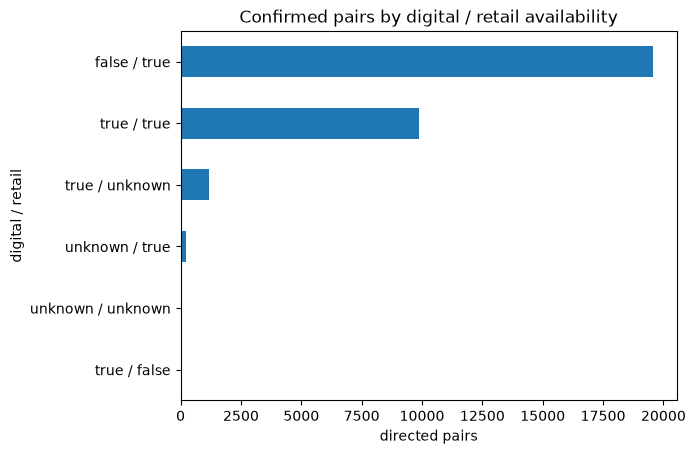

In [7]:
#@title 5. Channel combinations across confirmed pairs
channel_counts = (
    corridor_universe.loc[corridor_universe.product_status.eq("PRODUCT_CONFIRMED")]
    .groupby(["digital", "retail"], dropna=False)
    .size().rename("pairs").reset_index().sort_values("pairs", ascending=False)
)
display(channel_counts)
ax = channel_counts.assign(combination=channel_counts.digital.astype(str) + " / " + channel_counts.retail.astype(str)).plot.barh(
    x="combination", y="pairs", legend=False, title="Confirmed pairs by digital / retail availability"
)
ax.invert_yaxis(); ax.set_xlabel("directed pairs"); ax.set_ylabel("digital / retail")


In [8]:
#@title 6. Product and service mix
service_counts = (
    corridor_products.groupby(["service_id", "service_name"], dropna=False).size()
    .rename("product_rows").reset_index().sort_values("product_rows", ascending=False)
)
display(service_counts.head(25))

payout_mix = corridor_products[["cash_pickup", "bank_payout", "wallet_payout"]].apply(lambda c: c.eq(True).sum()).rename("product_rows")
display(payout_mix.to_frame())


,service_id,service_name,product_rows
0,000,Money In Minutes,38937
12,500,Direct to Bank,7533
23,800,Mobile Money Transfer,2431
8,300,Next Day/Delayed Services,548
5,200,Direct To Card,496
10,500,DIRECT TO BANK,373
7,202,Direct To Card,264
6,201,Direct To Card,237
21,800,MOBILE MONEY TRANSFER,195
22,800,MOBILE WALLET,185


,product_rows
cash_pickup,39113
bank_payout,8287
wallet_payout,2975


In [9]:
#@title 7. Currency-configuration complexity
configuration_distribution = corridor_universe.configuration_count.value_counts().sort_index().rename("pairs").to_frame()
configuration_distribution["share"] = configuration_distribution.pairs / len(corridor_universe)
display(configuration_distribution.style.format({"share": "{:.1%}"}))
print("Maximum exact currency configurations observed for one pair:", int(corridor_universe.configuration_count.max()))


,pairs,share
configuration_count,,
0,7302,13.7%
1,29255,55.1%
2,11472,21.6%
3,3680,6.9%
4,1063,2.0%
6,311,0.6%
8,27,0.1%
9,18,0.0%
12,2,0.0%


Maximum exact currency configurations observed for one pair: 12


In [10]:
#@title 8. Reconciled top-ten modeled corridors
top10_view = top10[[
    "rank", "origin_name", "destination_name", "modeled_revenue_share", "digital", "retail",
    "cash_pickup", "bank_payout", "wallet_payout", "rank_stability", "model_evidence_strength", "limitations"
]].copy()
display(top10_view.style.format({"modeled_revenue_share": "{:.2%}"}))
print("Top-ten modeled share:", f"{top10.modeled_revenue_share.sum():.2%}")
print("Reminder: this is a modeled allocation; WU does not disclose corridor revenue.")


,rank,origin_name,destination_name,modeled_revenue_share,digital,retail,cash_pickup,bank_payout,wallet_payout,rank_stability,model_evidence_strength,limitations
0,1,United States,Mexico,7.89%,True,True,True,True,true,HIGH,HIGH,Modeled allocation; WU does not disclose corridor revenue
1,2,United States,India,3.27%,True,True,True,True,unknown,HIGH,HIGH,Modeled allocation; WU does not disclose corridor revenue
2,3,United States,Guatemala,2.36%,True,True,True,True,true,HIGH,HIGH,Modeled allocation; WU does not disclose corridor revenue
3,4,United States,Philippines,1.70%,True,True,True,True,true,HIGH,HIGH,Modeled allocation; WU does not disclose corridor revenue
4,5,United Arab Emirates,India,1.54%,False,True,True,True,unknown,MEDIUM,MEDIUM,Modeled allocation; WU does not disclose corridor revenue; medium rank stability
5,6,United States,Dominican Republic,1.07%,True,True,True,True,unknown,MEDIUM,HIGH,Modeled allocation; WU does not disclose corridor revenue; medium rank stability
6,7,United States,El Salvador,0.91%,True,True,True,True,unknown,MEDIUM,HIGH,Modeled allocation; WU does not disclose corridor revenue; medium rank stability
7,8,United Kingdom,India,0.90%,True,True,True,True,unknown,MEDIUM,MEDIUM,Modeled allocation; WU does not disclose corridor revenue; medium rank stability
8,9,Saudi Arabia,India,0.89%,False,True,True,True,unknown,MEDIUM,MEDIUM,Modeled allocation; WU does not disclose corridor revenue; medium rank stability
9,10,United States,China,0.85%,True,True,True,True,true,MEDIUM,HIGH,Modeled allocation; WU does not disclose corridor revenue; medium rank stability


Top-ten modeled share: 21.39%
Reminder: this is a modeled allocation; WU does not disclose corridor revenue.


In [11]:
#@title 9. Rank and share stability for the final top ten
stability_keyed = rank_stability.dropna(subset=["origin_wu_code", "destination_wu_code"]).drop_duplicates(
    ["origin_wu_code", "destination_wu_code"]
)
stability_view = top10[["rank", "origin_wu_code", "destination_wu_code", "origin_name", "destination_name"]].merge(
    stability_keyed[["origin_wu_code", "destination_wu_code", "rank_min", "rank_max", "median_rank", "top10_frequency", "modeled_share_min", "modeled_share_max", "scenario_count"]],
    on=["origin_wu_code", "destination_wu_code"], how="left", validate="one_to_one"
)
display(stability_view.style.format({
    "top10_frequency": "{:.0%}", "modeled_share_min": "{:.2%}", "modeled_share_max": "{:.2%}", "median_rank": "{:.1f}"
}))
print("Final top-ten corridors present in all 12 scenarios:", int(stability_view.top10_frequency.eq(1).sum()), "of 10")


,rank,origin_wu_code,destination_wu_code,origin_name,destination_name,rank_min,rank_max,median_rank,top10_frequency,modeled_share_min,modeled_share_max,scenario_count
0,1,US,MX,United States,Mexico,1,1,1.0,100%,4.48%,12.22%,12
1,2,US,IN,United States,India,2,2,2.0,100%,2.31%,4.05%,12
2,3,US,GT,United States,Guatemala,3,4,3.0,100%,1.81%,2.70%,12
3,4,US,PH,United States,Philippines,4,6,4.0,100%,1.42%,1.80%,12
4,5,AE,IN,United Arab Emirates,India,3,12,5.0,67%,0.75%,2.74%,12
5,6,US,DO,United States,Dominican Republic,5,11,6.0,83%,0.92%,1.15%,12
6,7,US,SV,United States,El Salvador,6,14,7.5,67%,0.75%,1.02%,12
7,8,GB,IN,United Kingdom,India,5,23,9.0,67%,0.42%,1.69%,12
8,9,SA,IN,Saudi Arabia,India,7,18,8.5,67%,0.50%,1.38%,12
9,10,US,CN,United States,China,7,17,10.5,50%,0.69%,0.97%,12


Final top-ten corridors present in all 12 scenarios: 4 of 10


In [12]:
#@title 10. US → Mexico detailed quote offers
quote_rows = []
for service in US_MX_raw_quote["response"].get("services_groups", []):
    service_fields = {key: value for key, value in service.items() if key != "pay_groups"}
    for offer in service.get("pay_groups", []):
        quote_rows.append({**service_fields, **offer})
US_MX_QUOTE_OFFERS = pd.DataFrame(quote_rows)
offer_columns = [
    "service", "service_name", "fund_out", "fund_out_mnem", "fund_in", "send_amount", "receive_amount",
    "gross_fee", "fx_rate", "fund_in_speed", "fund_out_speed", "speed_indicator", "min_amount", "max_amount", "max_payout"
]
display(US_MX_QUOTE_OFFERS[[c for c in offer_columns if c in US_MX_QUOTE_OFFERS]].sort_values(["service", "gross_fee", "fund_in"]))
print("Detailed offers:", len(US_MX_QUOTE_OFFERS))
print("Raw response status:", US_MX_raw_quote["response"]["response_status"])


,service,service_name,fund_out,fund_out_mnem,fund_in,send_amount,receive_amount,gross_fee,fx_rate,fund_in_speed,fund_out_speed,speed_indicator,min_amount,max_amount,max_payout
2,000,Money In Minutes,000,MM,CA,100,1624,3.00,16.2357,0,0,0,0,1.000000e+10,126759.18
1,000,Money In Minutes,000,MM,AC,100,1664,3.99,16.6330,4,0,0-4,0,1.000000e+10,126759.18
4,000,Money In Minutes,000,MM,AD,100,1664,3.99,16.6330,0,0,0,0,1.000000e+09,126759.18
7,000,Money In Minutes,000,MM,AP,100,1664,3.99,16.6330,0,0,0,0,1.000000e+10,126759.18
6,000,Money In Minutes,000,MM,DC,100,1664,3.99,16.6330,0,0,0,0,1.000000e+10,126759.18
3,000,Money In Minutes,000,MM,AR,100,1664,6.99,16.6330,0,0,0,0,1.000000e+09,126759.18
0,000,Money In Minutes,000,MM,CC,100,1664,6.99,16.6330,0,0,0,0,1.000000e+10,126759.18
5,000,Money In Minutes,000,MM,GP,100,1664,6.99,16.6330,0,0,0,0,1.000000e+10,126759.18
9,500,Direct to Bank,500,DB,AC,100,1655,1.99,16.5485,4,0,0-4,0,1.000000e+10,126759.18
12,500,Direct to Bank,500,DB,AD,100,1655,1.99,16.5485,0,0,0,0,1.000000e+09,126759.18


Detailed offers: 23
Raw response status: {'code': 'P0000', 'long_message': 'NO ERRORS--NO WARNINGS.6313493.2026-09-07 13:18:56.218_2026-09-07 13:18:56.340', 'message': 'OK.SUCCESSFUL PROCESSING', 'status': 0}


In [13]:
#@title 11. Field inventory by dataset
field_inventory = pd.concat([
    pd.DataFrame({"dataset": name, "field": frame.columns, "dtype": [str(dtype) for dtype in frame.dtypes]})
    for name, frame in DATA.items()
], ignore_index=True)
display(field_inventory)
print("Tabular fields cataloged:", len(field_inventory))
print("US→MX full dossier sections:", list(US_MX_pair_dossier["records"]))


,dataset,field,dtype
0,corridor_products,corridor_id,str
1,corridor_products,origin_wu_code,str
2,corridor_products,destination_wu_code,str
3,corridor_products,send_currency,str
4,corridor_products,payout_currency,str
...,...,...,...
126,top10,bank_payout,bool
127,top10,wallet_payout,str
128,top10,rank_stability,str
129,top10,model_evidence_strength,str


Tabular fields cataloged: 131
US→MX full dossier sections: ['corridor_universe', 'corridor_products', 'rank_stability', 'reconciled_top10', 'graph_markets', 'graph_corridors', 'graph_corridor_channels', 'graph_edges', 'q12_q13_corridor_summary']


In [14]:
#@title 12. Scratchpad — choose another directional pair
ORIGIN = "US"
DESTINATION = "IN"
CUSTOM_PAIR = select_pair(ORIGIN, DESTINATION)
show_pair(CUSTOM_PAIR)


,dataset,records,fields
0,corridor_products,2,24
1,corridor_universe,1,30
2,graph_channels,1,13
3,graph_corridors,1,10
4,markets,2,5
5,q12_q13_summary,1,16
6,rank_stability,1,17
7,top10,1,16



corridor_products: 2 record(s)


,corridor_id,origin_wu_code,destination_wu_code,send_currency,payout_currency,product_row_id,service_id,service_name,fund_out,fund_out_mnemonic,...,wallet_payout,funding_methods,payout_methods,speed,request_hash,response_hash,payload_fingerprint,timestamp,http_status,raw_evidence_path
49273,US->IN,US,IN,USD,INR,a3f2e4c81ffbce55bf5d6197be4114c2113b2045a4dd70...,000,Money In Minutes,000,MM,...,None,"[""AC"",""AD"",""AP"",""AR"",""CA"",""CC"",""DC"",""GP""]","[""000"",""MM""]",0|0-4,a3f2e4c81ffbce55bf5d6197be4114c2113b2045a4dd70...,39641a8110edfea7a1bce9b61a828045ba2fae6a4afeff...,9d8af152622bd2193e2a9a0898664d2fe0f4b0ff25699e...,2026-09-07T13:18:52+00:00,NaN,raw\quotes\a3f2e4c81ffbce55bf5d6197be4114c2113...
49274,US->IN,US,IN,USD,INR,a3f2e4c81ffbce55bf5d6197be4114c2113b2045a4dd70...,500,Direct to Bank,500,DB,...,None,"[""AC"",""AD"",""AP"",""AR"",""CA"",""CC"",""DC"",""GP""]","[""500"",""DB""]",0|0-1|0-4,a3f2e4c81ffbce55bf5d6197be4114c2113b2045a4dd70...,39641a8110edfea7a1bce9b61a828045ba2fae6a4afeff...,9d8af152622bd2193e2a9a0898664d2fe0f4b0ff25699e...,2026-09-07T13:18:52+00:00,NaN,raw\quotes\a3f2e4c81ffbce55bf5d6197be4114c2113...



corridor_universe: 1 record(s)


,corridor_id,origin_wu_code,destination_wu_code,origin_name,destination_name,origin_iso2_secondary,destination_iso2_secondary,origin_iso3_secondary,destination_iso3_secondary,origin_mapping_status,...,payout_currencies,request_hashes,response_hashes,latest_timestamp,digital,retail,cash_pickup,bank_payout,wallet_payout,channel_evidence_basis
48621,US->IN,US,IN,United States,India,US,IN,USA,IND,direct_code,...,"[""INR""]","[""a3f2e4c81ffbce55bf5d6197be4114c2113b2045a4dd...","[""39641a8110edfea7a1bce9b61a828045ba2fae6a4afe...",2026-09-07T13:18:52+00:00,true,true,true,true,unknown,pair_product_response


...

,corridor,modeled_revenue_share,send_wu_sites,receive_wu_sites,send_confirmed_multibrand_pct,receive_confirmed_multibrand_pct,send_wu_p50_miles,send_wu_p90_miles,receive_wu_p50_miles,receive_wu_p90_miles,send_moneygram_p50_miles,send_ria_p50_miles,receive_moneygram_p50_miles,receive_ria_p50_miles,wu_relative_access_advantage,service_exclusivity_evidence_quality
1,US->IN,0.033718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,send:NO_WU_AFFIRMATIVE_CONTRACT_EVIDENCE;recei...



rank_stability: 1 record(s)


,corridor,send_iso3,receive_iso3,origin_wu_code,destination_wu_code,rank_min,rank_max,median_rank,top10_frequency,modeled_share_min,modeled_share_max,rank_stability,product_confirmed,product_status,digital,retail,scenario_count
1,United States of America -> India,USA,IND,US,IN,2,2,2.0,1.0,0.023103,0.040547,HIGH,True,PRODUCT_CONFIRMED,true,true,12



top10: 1 record(s)


,rank,origin_wu_code,destination_wu_code,origin_name,destination_name,modeled_revenue_share,share_perimeter,product_confirmed,digital,retail,cash_pickup,bank_payout,wallet_payout,rank_stability,model_evidence_strength,limitations
1,2,US,IN,United States,India,0.032664,FY2025 consolidated revenue; cross-border CMT ...,True,True,True,True,True,unknown,HIGH,HIGH,Modeled allocation; WU does not disclose corri...


## RPW → Western Union competitive-footprint reconstruction

This section recreates and improves the Statista-style Western Union sender/receiver “market share” charts directly from the World Bank Remittance Prices Worldwide (`rpw_history`) raw observations. These metrics are **shares of observed RPW provider/product quotes, not transaction-value market share**.

Outputs:
- corridor-level WU presence, quote share, provider share, competitive intensity and price rank;
- sender-country and receiver-country WU footprint tables;
- cash vs digital WU footprint where channel fields exist;
- latest-period and historical trend views;
- merge to `bilateral_remittance_2024` for economic weighting;
- diagnostics that flag schema mismatches and coverage limitations.

The cells are schema-tolerant because RPW workbook column names can vary by vintage. Run the roadmap-pack loader first so `rpw_history` and `bilateral_remittance_2024` exist.


In [15]:
#@title 13. RPW schema discovery and normalization
import re
import numpy as np
import pandas as pd
from IPython.display import display

if "rpw_history" not in globals():
    raise NameError("Run the roadmap-pack loader first; rpw_history is not loaded.")

RPW = rpw_history.copy()
print(f"rpw_history: {len(RPW):,} rows × {RPW.shape[1]} columns")
display(pd.DataFrame({"column": RPW.columns, "dtype": RPW.dtypes.astype(str).values}))

# Flexible column resolver. It first prefers exact normalized names, then substring matches.
def _norm_name(x):
    return re.sub(r"[^a-z0-9]+", "_", str(x).strip().lower()).strip("_")

_norm_to_original = {_norm_name(c): c for c in RPW.columns}

def pick_col(*candidates, required=False):
    norms = [_norm_name(x) for x in candidates]
    for n in norms:
        if n in _norm_to_original:
            return _norm_to_original[n]
    for n in norms:
        hits = [orig for nn, orig in _norm_to_original.items() if n in nn or nn in n]
        if len(hits) == 1:
            return hits[0]
    if required:
        raise KeyError(f"Could not resolve any of {candidates}. Available columns: {list(RPW.columns)}")
    return None

COL = {
    "send": pick_col("source_name", "send_country", "sending_country", "source_country", "origin_country", "send economy", required=True),
    "receive": pick_col("destination_name", "receive_country", "receiving_country", "destination_country", "recipient_country", "receive economy", required=True),
    "provider": pick_col("firm", "provider", "service_provider", "mto", required=True),
    "period": pick_col("period", "quarter", "survey_period", "date", "year_quarter", "time"),
    "year": pick_col("year"),
    "quarter": pick_col("quarter", "qtr"),
    "product": pick_col("product", "product_name", "service", "service_name"),
    "channel": pick_col("access_point", "channel", "send_channel", "access channel"),
    "payment": pick_col("payment_instrument", "payment_method", "funding_method"),
    "receive_method": pick_col("pickup_method", "receiving_method", "receive_method", "payout_method", "delivery_method"),
    "cost": pick_col("cc1_total_cost", "cc1 total cost %", "total_cost_percent", "total_cost", "total_cost_percentage", "cost_percent", "total cost %"),
    "fee": pick_col("cc1_lcu_fee", "cc1 lcu fee", "fee", "transfer_fee", "fee_percent"),
    "fx_margin": pick_col("cc1_fx_margin", "cc1 fx margin", "exchange_rate_margin", "fx_margin", "exchange_rate_margin_percent"),
    "speed": pick_col("speed_actual", "speed actual", "speed", "transfer_speed", "time"),
}
print("Resolved columns:")
display(pd.Series(COL, name="RPW column").to_frame())

# Canonical normalized fields.
r = pd.DataFrame(index=RPW.index)
r["send_country"] = RPW[COL["send"]].astype(str).str.strip()
r["receive_country"] = RPW[COL["receive"]].astype(str).str.strip()
r["provider"] = RPW[COL["provider"]].astype(str).str.strip()
r["provider_norm"] = r["provider"].str.lower().str.replace(r"[^a-z0-9]+", " ", regex=True).str.strip()
r["is_wu"] = r["provider_norm"].str.contains(r"\bwestern\s+union\b|\bwesternunion\b", regex=True, na=False)
r["corridor"] = r["send_country"] + " → " + r["receive_country"]

for key in ["product","channel","payment","receive_method","speed"]:
    r[key] = RPW[COL[key]].astype(str).str.strip() if COL[key] else pd.NA
for key in ["cost","fee","fx_margin"]:
    r[key] = pd.to_numeric(RPW[COL[key]], errors="coerce") if COL[key] else np.nan

# Build a sortable period key.
if COL["period"]:
    r["period_raw"] = RPW[COL["period"]].astype(str)
elif COL["year"]:
    q = RPW[COL["quarter"]].astype(str) if COL["quarter"] else ""
    r["period_raw"] = RPW[COL["year"]].astype(str) + (" Q" + q if COL["quarter"] else "")
else:
    r["period_raw"] = "all"

def period_sort_key(x):
    s = str(x)
    y = re.search(r"(20\d{2}|19\d{2})", s)
    q = re.search(r"(?:Q|quarter\s*)([1-4])", s, flags=re.I)
    return (int(y.group(1)) if y else -1, int(q.group(1)) if q else 0, s)

periods = sorted(r["period_raw"].dropna().unique(), key=period_sort_key)
LATEST_RPW_PERIOD = periods[-1] if periods else "all"
print("Detected latest RPW period:", LATEST_RPW_PERIOD)
print("WU rows:", f"{int(r.is_wu.sum()):,}", f"({r.is_wu.mean():.2%} of raw RPW rows)")
print("Observed corridors:", f"{r.corridor.nunique():,}")


rpw_history: 253,960 rows × 49 columns


,column,dtype
0,id,str
1,period,str
2,source_code,str
3,source_name,str
4,source_region,str
5,source_income,str
6,source_lending,str
7,source_G8G20,str
8,destination_code,str
9,destination_name,str


Resolved columns:


,RPW column
send,source_name
receive,destination_name
provider,firm
period,period
year,NaN
quarter,NaN
product,product
channel,access point
payment,payment instrument
receive_method,pickup method


Detected latest RPW period: 2025_3Q
WU rows: 44,368 (17.47% of raw RPW rows)
Observed corridors: 388


In [16]:
#@title 14. Latest-period WU footprint by corridor
LATEST = r.loc[r["period_raw"].eq(LATEST_RPW_PERIOD)].copy()
if LATEST.empty:
    raise ValueError("Latest-period filter returned zero rows; inspect period_raw values above.")

# One provider count per corridor; quote/product rows remain observation-level.
def corridor_metrics(g):
    providers = g["provider_norm"].dropna()
    wu = g[g["is_wu"]]
    provider_count = providers.nunique()
    return pd.Series({
        "rpw_quotes": len(g),
        "wu_quotes": len(wu),
        "wu_quote_share": len(wu) / len(g) if len(g) else np.nan,
        "providers": provider_count,
        "wu_present": bool(len(wu)),
        "wu_provider_share": (1 / provider_count) if len(wu) and provider_count else 0.0,
        "wu_products": wu["product"].nunique(dropna=True) if "product" in wu else np.nan,
        "all_products": g["product"].nunique(dropna=True) if "product" in g else np.nan,
        "median_cost_all": g["cost"].median(),
        "median_cost_wu": wu["cost"].median(),
        "min_cost_all": g["cost"].min(),
        "min_cost_wu": wu["cost"].min(),
    })

RPW_WU_CORRIDOR_LATEST = (
    LATEST.groupby(["send_country","receive_country","corridor"], dropna=False)
    .apply(corridor_metrics, include_groups=False)
    .reset_index()
)
RPW_WU_CORRIDOR_LATEST["wu_cost_premium_vs_median"] = (
    RPW_WU_CORRIDOR_LATEST["median_cost_wu"] - RPW_WU_CORRIDOR_LATEST["median_cost_all"]
)
RPW_WU_CORRIDOR_LATEST["wu_cost_premium_pct"] = (
    RPW_WU_CORRIDOR_LATEST["median_cost_wu"] / RPW_WU_CORRIDOR_LATEST["median_cost_all"] - 1
)

# Corridor-level cost percentile for WU: 0 = cheapest, 1 = most expensive.
def wu_cost_percentile(g):
    d = g.dropna(subset=["cost"]).copy()
    if d.empty or not d["is_wu"].any():
        return np.nan
    d["pct_rank"] = d["cost"].rank(method="average", pct=True)
    return d.loc[d.is_wu, "pct_rank"].median()

cost_pct = (
    LATEST.groupby(["send_country","receive_country"], dropna=False)
    .apply(wu_cost_percentile, include_groups=False)
    .rename("wu_cost_percentile")
    .reset_index()
)
RPW_WU_CORRIDOR_LATEST = RPW_WU_CORRIDOR_LATEST.merge(cost_pct, on=["send_country","receive_country"], how="left")

print("Latest-period corridor footprint")
display(
    RPW_WU_CORRIDOR_LATEST.sort_values(["wu_present","wu_quote_share","rpw_quotes"], ascending=[False,False,False])
    .head(40)
    .style.format({"wu_quote_share":"{:.1%}","wu_provider_share":"{:.1%}","wu_cost_premium_pct":"{:.1%}","wu_cost_percentile":"{:.0%}"})
)


Latest-period corridor footprint


,send_country,receive_country,corridor,rpw_quotes,wu_quotes,wu_quote_share,providers,wu_present,wu_provider_share,wu_products,all_products,median_cost_all,median_cost_wu,min_cost_all,min_cost_wu,wu_cost_premium_vs_median,wu_cost_premium_pct,wu_cost_percentile
200,Saudi Arabia,South Sudan,Saudi Arabia → South Sudan,1,1,100.0%,1,True,100.0%,0,0,4.830000,4.830000,4.830000,4.830000,0.000000,0.0%,100%
203,Saudi Arabia,Syrian Arab Republic,Saudi Arabia → Syrian Arab Republic,1,1,100.0%,1,True,100.0%,0,0,8.880000,8.880000,8.880000,8.880000,0.000000,0.0%,100%
298,United Kingdom,South Sudan,United Kingdom → South Sudan,10,7,70.0%,4,True,25.0%,0,0,7.060000,6.230000,4.750000,4.750000,-0.830000,-11.8%,45%
186,Qatar,Sudan,Qatar → Sudan,3,2,66.7%,2,True,50.0%,0,0,33.690000,33.690000,2.230000,33.690000,0.000000,0.0%,83%
196,Saudi Arabia,Myanmar,Saudi Arabia → Myanmar,3,2,66.7%,3,True,33.3%,0,0,4.930000,4.655000,4.380000,4.380000,-0.275000,-5.6%,50%
269,United Arab Emirates,South Sudan,United Arab Emirates → South Sudan,3,2,66.7%,2,True,50.0%,0,0,2.970000,3.685000,2.700000,2.700000,0.715000,24.1%,67%
32,Brazil,Paraguay,Brazil → Paraguay,10,6,60.0%,4,True,25.0%,0,0,6.430000,5.485000,2.740000,2.740000,-0.945000,-14.7%,40%
72,Germany,Afghanistan,Germany → Afghanistan,5,3,60.0%,2,True,50.0%,0,0,7.730000,7.730000,6.680000,7.730000,0.000000,0.0%,70%
83,Germany,Lebanon,Germany → Lebanon,5,3,60.0%,2,True,50.0%,0,0,4.320000,4.320000,3.000000,4.320000,0.000000,0.0%,70%
246,Switzerland,Hungary,Switzerland → Hungary,13,7,53.8%,4,True,25.0%,0,0,3.120000,2.820000,0.630000,0.630000,-0.300000,-9.6%,46%


In [17]:
#@title 15. Recreate Statista-style WU footprint by sender and receiver
# IMPORTANT: these are RPW observation/provider-presence metrics, NOT actual remittance market shares.

def country_footprint(df, side):
    other = "receive_country" if side == "send_country" else "send_country"
    rows = []
    for country, g in df.groupby(side, dropna=False):
        corridors = g[[side, other]].drop_duplicates()
        wu_corridors = g.loc[g.is_wu, [side, other]].drop_duplicates()
        providers_by_corr = g.groupby(other)["provider_norm"].nunique()
        wu_by_corr = g[g.is_wu].groupby(other).size().gt(0)
        provider_share = wu_by_corr.reindex(providers_by_corr.index, fill_value=False).astype(float).div(providers_by_corr)
        rows.append({
            side: country,
            "rpw_quotes": len(g),
            "wu_quotes": int(g.is_wu.sum()),
            "wu_quote_share": g.is_wu.mean(),
            "corridors_observed": len(corridors),
            "wu_corridors_present": len(wu_corridors),
            "wu_corridor_presence_rate": len(wu_corridors)/len(corridors) if len(corridors) else np.nan,
            "avg_wu_provider_share_across_corridors": provider_share.mean() if len(provider_share) else np.nan,
            "median_wu_cost": g.loc[g.is_wu,"cost"].median(),
            "median_market_cost": g["cost"].median(),
        })
    out = pd.DataFrame(rows)
    out["wu_cost_premium_pct"] = out["median_wu_cost"] / out["median_market_cost"] - 1
    return out

RPW_WU_BY_SENDER = country_footprint(LATEST, "send_country").sort_values("wu_quote_share", ascending=False, ignore_index=True)
RPW_WU_BY_RECEIVER = country_footprint(LATEST, "receive_country").sort_values("wu_quote_share", ascending=False, ignore_index=True)

print("Statista-style reconstruction — sender countries")
display(RPW_WU_BY_SENDER.head(30).style.format({c:"{:.1%}" for c in ["wu_quote_share","wu_corridor_presence_rate","avg_wu_provider_share_across_corridors","wu_cost_premium_pct"]}))
print("Statista-style reconstruction — receiver countries")
display(RPW_WU_BY_RECEIVER.head(30).style.format({c:"{:.1%}" for c in ["wu_quote_share","wu_corridor_presence_rate","avg_wu_provider_share_across_corridors","wu_cost_premium_pct"]}))


Statista-style reconstruction — sender countries


,send_country,rpw_quotes,wu_quotes,wu_quote_share,corridors_observed,wu_corridors_present,wu_corridor_presence_rate,avg_wu_provider_share_across_corridors,median_wu_cost,median_market_cost,wu_cost_premium_pct
0,Angola,2,1,50.0%,1,1,100.0%,50.0%,9.940000,13.290000,-25.2%
1,Cameroon,2,1,50.0%,1,1,100.0%,50.0%,4.130000,4.380000,-5.7%
2,Brazil,28,12,42.9%,3,3,100.0%,20.6%,6.045000,6.245000,-3.2%
3,Switzerland,57,24,42.1%,5,5,100.0%,24.0%,5.115000,5.440000,-6.0%
4,Portugal,32,12,37.5%,3,3,100.0%,27.8%,4.850000,4.135000,17.3%
5,Thailand,128,47,36.7%,7,7,100.0%,10.1%,4.470000,14.045000,-68.2%
6,Israel,3,1,33.3%,1,1,100.0%,33.3%,16.980000,13.470000,26.1%
7,Dominican Republic,3,1,33.3%,1,1,100.0%,33.3%,7.910000,7.910000,0.0%
8,Qatar,49,16,32.7%,9,9,100.0%,25.7%,2.715000,3.130000,-13.3%
9,Oman,42,12,28.6%,6,6,100.0%,19.9%,3.300000,3.310000,-0.3%


Statista-style reconstruction — receiver countries


,receive_country,rpw_quotes,wu_quotes,wu_quote_share,corridors_observed,wu_corridors_present,wu_corridor_presence_rate,avg_wu_provider_share_across_corridors,median_wu_cost,median_market_cost,wu_cost_premium_pct
0,Paraguay,10,6,60.0%,1,1,100.0%,25.0%,5.485000,6.430000,-14.7%
1,Namibia,2,1,50.0%,1,1,100.0%,50.0%,9.940000,13.290000,-25.2%
2,Afghanistan,16,7,43.8%,4,4,100.0%,45.8%,7.800000,7.765000,0.5%
3,North Macedonia,7,3,42.9%,1,1,100.0%,33.3%,3.560000,3.560000,0.0%
4,Albania,60,25,41.7%,4,4,100.0%,21.5%,4.580000,5.330000,-14.1%
5,Sudan,10,4,40.0%,3,3,100.0%,41.7%,33.150000,32.480000,2.1%
6,Lao PDR,16,6,37.5%,1,1,100.0%,10.0%,3.525000,15.520000,-77.3%
7,Comoros,11,4,36.4%,1,1,100.0%,20.0%,3.050000,3.140000,-2.9%
8,Madagascar,14,5,35.7%,1,1,100.0%,20.0%,4.630000,4.630000,0.0%
9,Hungary,50,17,34.0%,3,3,100.0%,19.2%,6.720000,3.970000,69.3%


In [18]:
#@title 16. Cash vs digital footprint (best-effort channel classification)
text_fields = [c for c in ["channel","payment","receive_method","product"] if c in LATEST.columns]
channel_text = LATEST[text_fields].fillna("").astype(str).agg(" | ".join, axis=1).str.lower()
LATEST_CH = LATEST.copy()
LATEST_CH["digital_flag"] = channel_text.str.contains(r"online|internet|mobile|app|wallet|bank account|account deposit|debit|credit", regex=True)
LATEST_CH["cash_flag"] = channel_text.str.contains(r"cash|agent|branch|retail|counter|pickup|pick-up", regex=True)
LATEST_CH["channel_bucket"] = np.select(
    [LATEST_CH.cash_flag & ~LATEST_CH.digital_flag, LATEST_CH.digital_flag & ~LATEST_CH.cash_flag, LATEST_CH.cash_flag & LATEST_CH.digital_flag],
    ["cash/retail", "digital/account", "hybrid/ambiguous"],
    default="unclassified"
)

RPW_WU_CHANNEL_MIX = (
    LATEST_CH.groupby("channel_bucket")
    .agg(rpw_quotes=("is_wu","size"), wu_quotes=("is_wu","sum"), corridors=("corridor","nunique"))
    .reset_index()
)
RPW_WU_CHANNEL_MIX["wu_quote_share"] = RPW_WU_CHANNEL_MIX.wu_quotes / RPW_WU_CHANNEL_MIX.rpw_quotes
print("Heuristic classification only; inspect the underlying RPW fields before using this as a hard statistic.")
display(RPW_WU_CHANNEL_MIX.style.format({"wu_quote_share":"{:.1%}"}))


Heuristic classification only; inspect the underlying RPW fields before using this as a hard statistic.


,channel_bucket,rpw_quotes,wu_quotes,corridors,wu_quote_share
0,cash/retail,887,273,317,30.8%
1,digital/account,2385,215,294,9.0%
2,hybrid/ambiguous,3198,656,334,20.5%


,period_raw,rpw_quotes,wu_quotes,corridors,wu_corridors,providers,wu_quote_share,wu_corridor_presence_rate
0,2011_1Q,2603,299,199,187,351,11.5%,94.0%
1,2011_3Q,2668,363,213,208,352,13.6%,97.7%
2,2012_1Q,2638,365,208,201,368,13.8%,96.6%
3,2012_3Q,2907,421,219,213,375,14.5%,97.3%
4,2013_1Q,2924,439,220,214,372,15.0%,97.3%
5,2013_2Q,2948,454,220,214,374,15.4%,97.3%
6,2013_3Q,2941,453,220,214,374,15.4%,97.3%
7,2013_4Q,2904,445,220,213,385,15.3%,96.8%
8,2014_1Q,2983,457,226,222,403,15.3%,98.2%
9,2014_2Q,2951,484,226,223,406,16.4%,98.7%


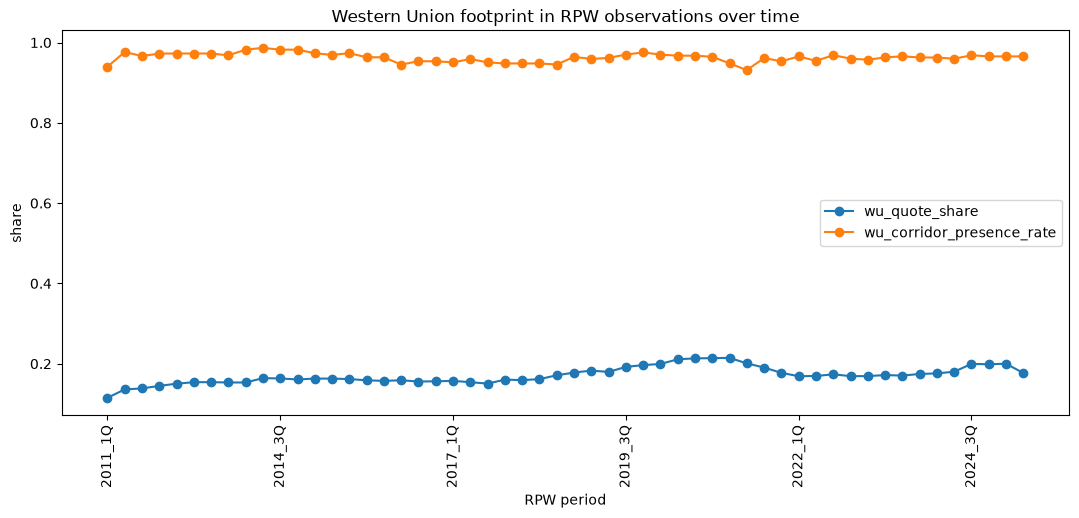

In [19]:
#@title 17. Historical trend in WU RPW footprint
RPW_WU_TREND = (
    r.groupby("period_raw", dropna=False)
    .agg(
        rpw_quotes=("is_wu","size"),
        wu_quotes=("is_wu","sum"),
        corridors=("corridor","nunique"),
        wu_corridors=("corridor", lambda x: x[r.loc[x.index,"is_wu"]].nunique()),
        providers=("provider_norm","nunique")
    )
    .reset_index()
)
RPW_WU_TREND["wu_quote_share"] = RPW_WU_TREND.wu_quotes / RPW_WU_TREND.rpw_quotes
RPW_WU_TREND["wu_corridor_presence_rate"] = RPW_WU_TREND.wu_corridors / RPW_WU_TREND.corridors
RPW_WU_TREND["_sort"] = RPW_WU_TREND.period_raw.map(period_sort_key)
RPW_WU_TREND = RPW_WU_TREND.sort_values("_sort").drop(columns="_sort").reset_index(drop=True)
display(RPW_WU_TREND.style.format({"wu_quote_share":"{:.1%}","wu_corridor_presence_rate":"{:.1%}"}))

ax = RPW_WU_TREND.plot(x="period_raw", y=["wu_quote_share","wu_corridor_presence_rate"], figsize=(13,5), marker="o", title="Western Union footprint in RPW observations over time")
ax.set_ylabel("share"); ax.set_xlabel("RPW period"); ax.tick_params(axis="x", rotation=90)


In [20]:
#@title 18. Merge RPW footprint with 2024 bilateral remittance flows
if "bilateral_flows" not in globals():
    bilateral_flows = bilateral_remittance_2024.copy()
    bilateral_flows["flow_usd"] = pd.to_numeric(bilateral_flows.get("v"), errors="coerce")

# Country-name merge first. This is intentionally conservative: unmatched rows are retained for review.
b = bilateral_flows.copy()
for c in ["source_country","receive_country"]:
    if c in b.columns:
        b[c + "_key"] = b[c].astype(str).str.strip().str.lower().str.replace(r"[^a-z0-9]+", " ", regex=True).str.strip()

m = RPW_WU_CORRIDOR_LATEST.copy()
m["send_key"] = m.send_country.astype(str).str.lower().str.replace(r"[^a-z0-9]+", " ", regex=True).str.strip()
m["receive_key"] = m.receive_country.astype(str).str.lower().str.replace(r"[^a-z0-9]+", " ", regex=True).str.strip()

if {"source_country_key","receive_country_key"}.issubset(b.columns):
    RPW_BILATERAL_2024 = b.merge(
        m,
        left_on=["source_country_key","receive_country_key"],
        right_on=["send_key","receive_key"],
        how="left",
        suffixes=("_bilateral","_rpw")
    )
else:
    RPW_BILATERAL_2024 = b.copy()
    print("Bilateral table lacks source_country / receive_country names; use ISO mapping for a stronger merge.")

if "flow_usd" in RPW_BILATERAL_2024:
    matched = RPW_BILATERAL_2024.wu_present.notna() if "wu_present" in RPW_BILATERAL_2024 else pd.Series(False, index=RPW_BILATERAL_2024.index)
    print("Bilateral corridors matched to an RPW latest-period corridor:", f"{matched.sum():,} / {len(RPW_BILATERAL_2024):,}")
    print("Share of modeled bilateral dollars covered by matched RPW corridors:", f"{RPW_BILATERAL_2024.loc[matched,'flow_usd'].sum()/RPW_BILATERAL_2024.flow_usd.sum():.1%}")
    display(RPW_BILATERAL_2024.sort_values("flow_usd", ascending=False).head(30)[[
        c for c in ["source_country","receive_country","flow_usd","wu_present","wu_quote_share","providers","wu_cost_percentile","median_cost_wu","median_cost_all"] if c in RPW_BILATERAL_2024.columns
    ]].style.format({"flow_usd":"${:,.0f}","wu_quote_share":"{:.1%}","wu_cost_percentile":"{:.0%}"}))


Bilateral corridors matched to an RPW latest-period corridor: 241 / 8,572
Share of modeled bilateral dollars covered by matched RPW corridors: 34.9%


,source_country,flow_usd,wu_present,wu_quote_share,providers,wu_cost_percentile,median_cost_wu,median_cost_all
0,United States of America,"$65,855,005,077",nan,nan%,nan,nan%,nan,nan
1,United States of America,"$27,250,393,272",nan,nan%,nan,nan%,nan,nan
4,United Arab Emirates,"$26,334,542,340",True,8.3%,12.000000,52%,2.430000,3.045000
2,United States of America,"$19,680,528,363",nan,nan%,nan,nan%,nan,nan
6,Saudi Arabia,"$15,216,172,432",True,8.3%,8.000000,75%,4.140000,3.555000
3,United States of America,"$14,216,968,526",nan,nan%,nan,nan%,nan,nan
17,Saudi Arabia,"$10,565,730,481",True,8.3%,8.000000,8%,1.440000,3.060000
9,United Kingdom,"$10,443,491,625",True,10.7%,12.000000,50%,2.010000,2.060000
18,Kuwait,"$9,506,522,122",True,6.7%,8.000000,68%,2.510000,2.420000
19,Saudi Arabia,"$9,308,422,513",nan,nan%,nan,nan%,nan,nan


In [21]:
#@title 19. Economically weighted WU footprint proxies and top corridors
if "RPW_BILATERAL_2024" not in globals() or "flow_usd" not in RPW_BILATERAL_2024.columns:
    raise NameError("Run the bilateral merge cell first.")

w = RPW_BILATERAL_2024.dropna(subset=["flow_usd"]).copy()
# These are proxies, not estimated WU principal shares. Keep the names explicit.
w["flow_x_wu_quote_share"] = w["flow_usd"] * w["wu_quote_share"].fillna(0)
w["flow_x_wu_provider_share"] = w["flow_usd"] * w["wu_provider_share"].fillna(0)
w["flow_x_wu_presence"] = w["flow_usd"] * w["wu_present"].fillna(False).astype(float)

WU_FLOW_WEIGHTED_PROXY = w.sort_values("flow_x_wu_quote_share", ascending=False).copy()
cols = [c for c in ["source_country","receive_country","flow_usd","wu_present","wu_quote_share","wu_provider_share","providers","wu_cost_percentile","flow_x_wu_quote_share"] if c in w.columns]
display(WU_FLOW_WEIGHTED_PROXY[cols].head(40).style.format({
    "flow_usd":"${:,.0f}", "wu_quote_share":"{:.1%}", "wu_provider_share":"{:.1%}", "wu_cost_percentile":"{:.0%}", "flow_x_wu_quote_share":"${:,.0f}"
}))

covered = w[w.wu_quote_share.notna()]
if len(covered):
    flow_weighted_quote_share = np.average(covered.wu_quote_share, weights=covered.flow_usd)
    flow_weighted_provider_share = np.average(covered.wu_provider_share, weights=covered.flow_usd)
    print("Flow-weighted WU RPW quote share across matched corridors:", f"{flow_weighted_quote_share:.2%}")
    print("Flow-weighted WU provider-share proxy across matched corridors:", f"{flow_weighted_provider_share:.2%}")
print("Do NOT label either number as WU transaction/principal market share; they are economically weighted RPW footprint proxies.")


,source_country,flow_usd,wu_present,wu_quote_share,wu_provider_share,providers,wu_cost_percentile,flow_x_wu_quote_share
4,United Arab Emirates,"$26,334,542,340",True,8.3%,8.3%,12.000000,52%,"$2,194,545,195"
30,Qatar,"$6,551,456,432",True,28.6%,20.0%,5.000000,21%,"$1,871,844,695"
34,Oman,"$5,977,112,744",True,27.3%,12.5%,8.000000,45%,"$1,630,121,657"
6,Saudi Arabia,"$15,216,172,432",True,8.3%,12.5%,8.000000,75%,"$1,268,014,369"
37,United Kingdom,"$4,326,654,913",True,29.0%,11.1%,9.000000,79%,"$1,256,125,620"
8,Canada,"$7,594,507,109",True,15.6%,7.7%,13.000000,52%,"$1,186,641,736"
9,United Kingdom,"$10,443,491,625",True,10.7%,8.3%,12.000000,50%,"$1,118,945,531"
75,Germany,"$2,454,010,999",True,38.9%,20.0%,5.000000,89%,"$954,337,611"
17,Saudi Arabia,"$10,565,730,481",True,8.3%,12.5%,8.000000,8%,"$880,477,540"
83,Germany,"$2,138,284,877",True,41.2%,14.3%,7.000000,82%,"$880,470,243"


Flow-weighted WU RPW quote share across matched corridors: 15.74%
Flow-weighted WU provider-share proxy across matched corridors: 11.99%
Do NOT label either number as WU transaction/principal market share; they are economically weighted RPW footprint proxies.


In [22]:
#@title 20. Validation checks and known-management corridor lookups
checks = []
checks.append(("RPW rows > 0", len(r) > 0, len(r)))
checks.append(("WU identified", int(r.is_wu.sum()) > 0, int(r.is_wu.sum())))
checks.append(("Latest period rows > 0", len(LATEST) > 0, len(LATEST)))
checks.append(("Corridor shares bounded", RPW_WU_CORRIDOR_LATEST.wu_quote_share.between(0,1).all(), None))
checks.append(("Provider shares bounded", RPW_WU_CORRIDOR_LATEST.wu_provider_share.between(0,1).all(), None))
VALIDATION = pd.DataFrame(checks, columns=["check","passed","detail"])
display(VALIDATION)

# Search corridors management has discussed; this is a lookup aid, not a calibration by itself.
management_pairs = [
    ("United States","Mexico"),
    ("United States","India"),
    ("United States","Guatemala"),
    ("United States","Philippines"),
    ("United States","Dominican Republic"),
    ("United Arab Emirates","India"),
    ("Saudi Arabia","India"),
    ("United Kingdom","India"),
    ("Italy","Morocco"),
    ("France","Cameroon"),
    ("Kuwait","Bangladesh"),
]
lookup_rows=[]
for s,d in management_pairs:
    z=RPW_WU_CORRIDOR_LATEST[
        RPW_WU_CORRIDOR_LATEST.send_country.str.contains(s, case=False, regex=False, na=False) &
        RPW_WU_CORRIDOR_LATEST.receive_country.str.contains(d, case=False, regex=False, na=False)
    ]
    if len(z): lookup_rows.append(z.assign(requested_pair=f"{s} → {d}"))
MANAGEMENT_CORRIDOR_RPW = pd.concat(lookup_rows, ignore_index=True) if lookup_rows else pd.DataFrame()
if len(MANAGEMENT_CORRIDOR_RPW):
    display(MANAGEMENT_CORRIDOR_RPW[[c for c in ["requested_pair","send_country","receive_country","wu_present","wu_quote_share","providers","wu_provider_share","wu_cost_percentile","median_cost_wu","median_cost_all"] if c in MANAGEMENT_CORRIDOR_RPW.columns]].style.format({"wu_quote_share":"{:.1%}","wu_provider_share":"{:.1%}","wu_cost_percentile":"{:.0%}"}))
else:
    print("No exact management-pair name matches. Inspect country naming conventions and add aliases if needed.")


,check,passed,detail
0,RPW rows > 0,True,253960.0
1,WU identified,True,44368.0
2,Latest period rows > 0,True,6470.0
3,Corridor shares bounded,True,NaN
4,Provider shares bounded,True,NaN


,requested_pair,send_country,receive_country,wu_present,wu_quote_share,providers,wu_provider_share,wu_cost_percentile,median_cost_wu,median_cost_all
0,United States → Mexico,United States,Mexico,True,13.0%,15,6.7%,79%,5.900000,4.485000
1,United States → India,United States,India,True,19.6%,13,7.7%,65%,3.830000,2.750000
2,United States → Guatemala,United States,Guatemala,True,3.3%,11,9.1%,80%,5.030000,3.975000
3,United States → Philippines,United States,Philippines,True,12.1%,14,7.1%,62%,4.460000,3.960000
4,United States → Dominican Republic,United States,Dominican Republic,True,14.8%,12,8.3%,80%,5.810000,4.100000
5,United Arab Emirates → India,United Arab Emirates,India,True,8.3%,12,8.3%,52%,2.430000,3.045000
6,Saudi Arabia → India,Saudi Arabia,India,True,8.3%,8,12.5%,75%,4.140000,3.555000
7,United Kingdom → India,United Kingdom,India,True,10.7%,12,8.3%,50%,2.010000,2.060000
8,Italy → Morocco,Italy,Morocco,True,20.7%,14,7.1%,57%,3.620000,3.390000
9,France → Cameroon,France,Cameroon,True,15.0%,6,16.7%,78%,4.440000,2.315000


In [23]:
#@title 21. Export analysis tables to one Excel workbook
from pathlib import Path
OUT = Path.cwd() / 'local_outputs' / 'WU_RPW_Footprint_Analysis.xlsx'
OUT.parent.mkdir(parents=True, exist_ok=True)
with pd.ExcelWriter(OUT, engine='openpyxl') as xw:
    RPW_WU_CORRIDOR_LATEST.to_excel(xw, sheet_name='corridor_latest', index=False)
    RPW_WU_BY_SENDER.to_excel(xw, sheet_name='sender_footprint', index=False)
    RPW_WU_BY_RECEIVER.to_excel(xw, sheet_name='receiver_footprint', index=False)
    RPW_WU_CHANNEL_MIX.to_excel(xw, sheet_name='channel_mix', index=False)
    RPW_WU_TREND.to_excel(xw, sheet_name='historical_trend', index=False)
    if 'RPW_BILATERAL_2024' in globals():
        RPW_BILATERAL_2024.to_excel(xw, sheet_name='bilateral_2024_merge', index=False)
    if 'WU_FLOW_WEIGHTED_PROXY' in globals():
        WU_FLOW_WEIGHTED_PROXY.to_excel(xw, sheet_name='flow_weighted_proxy', index=False)
    VALIDATION.to_excel(xw, sheet_name='validation', index=False)
print('Saved:', OUT)


Saved: C:\Users\micha\OneDrive\Documents\ChatGPT\alphasensecheck\python_analysis\outputs\colab\local_outputs\WU_RPW_Footprint_Analysis.xlsx


## Notes

- Pair direction matters: `US→MX` and `MX→US` are separate records.
- `top10.modeled_revenue_share` is a modeled allocation because Western Union does not disclose corridor revenue.
- The embedded US→MX dossier and raw quote are available as `US_MX_pair_dossier` and `US_MX_raw_quote`.
- Change only the two codes in `select_pair()` to inspect another corridor.

## Extended provider concentration, pricing, and writeup analysis

This section turns RPW + 2024 bilateral flows into **comparative provider exposure proxies**, not reported revenues. It is designed to support Questions 2, 3, 5, 8 and 10 directly, with secondary evidence for Questions 6, 12 and 13.

Three deliberately separate concepts are reported:
1. **RPW footprint share** — provider presence / quote share in observed corridors.
2. **Flow-weighted principal proxy** — bilateral remittance flow × provider footprint share.
3. **Revenue-intensity proxy** — flow-weighted principal proxy × observed RPW total cost (%). This is a rough within-provider allocation proxy, not accounting revenue.

Use the revenue-intensity proxy primarily for **concentration within a provider** (top-10 corridors, top countries, HHI), not for comparing absolute revenue dollars across providers.


In [24]:
#@title 22. Build all-provider latest-period corridor panel
from math import log

# Provider aliases: preserve raw provider but consolidate obvious branding variants.
def canonical_provider(x):
    s = str(x).strip()
    n = re.sub(r"[^a-z0-9]+", " ", s.lower()).strip()
    rules = [
        (r"western\s*union|westernunion", "Western Union"),
        (r"moneygram", "MoneyGram"),
        (r"remitly", "Remitly"),
        (r"wise|transferwise", "Wise"),
        (r"ria\b|ria money", "Ria"),
        (r"worldremit", "WorldRemit"),
        (r"xoom", "Xoom"),
        (r"small world", "Small World"),
        (r"taptap send|taptapsend", "Taptap Send"),
        (r"sendwave", "Sendwave"),
        (r"revolut", "Revolut"),
        (r"xe money|xe\.com|\bxe\b", "XE"),
    ]
    for pat, label in rules:
        if re.search(pat, n): return label
    return re.sub(r"\s+", " ", s).strip()

LATEST_ALL = LATEST.copy()
LATEST_ALL["provider_canon"] = LATEST_ALL["provider"].map(canonical_provider)
LATEST_ALL["corridor"] = LATEST_ALL["send_country"] + " → " + LATEST_ALL["receive_country"]

# Provider-corridor quote metrics.
pc = (LATEST_ALL.groupby(["provider_canon","send_country","receive_country","corridor"], dropna=False)
      .agg(quotes=("provider_canon","size"),
           products=("product","nunique"),
           median_cost=("cost","median"),
           mean_cost=("cost","mean"),
           min_cost=("cost","min"),
           median_fee=("fee","median"),
           median_fx_margin=("fx_margin","median"))
      .reset_index())

# Corridor denominators.
cd = (LATEST_ALL.groupby(["send_country","receive_country","corridor"], dropna=False)
      .agg(total_quotes=("provider_canon","size"), providers=("provider_canon","nunique"),
           corridor_median_cost=("cost","median"), corridor_min_cost=("cost","min"))
      .reset_index())

PROVIDER_CORRIDOR_LATEST = pc.merge(cd, on=["send_country","receive_country","corridor"], how="left")
PROVIDER_CORRIDOR_LATEST["quote_share"] = PROVIDER_CORRIDOR_LATEST["quotes"] / PROVIDER_CORRIDOR_LATEST["total_quotes"]
PROVIDER_CORRIDOR_LATEST["equal_provider_share"] = 1 / PROVIDER_CORRIDOR_LATEST["providers"].replace(0,np.nan)
PROVIDER_CORRIDOR_LATEST["cost_vs_corridor_median_pp"] = PROVIDER_CORRIDOR_LATEST["median_cost"] - PROVIDER_CORRIDOR_LATEST["corridor_median_cost"]
PROVIDER_CORRIDOR_LATEST["cost_premium_pct"] = PROVIDER_CORRIDOR_LATEST["median_cost"] / PROVIDER_CORRIDOR_LATEST["corridor_median_cost"] - 1

print(f"Latest period: {LATEST_RPW_PERIOD}")
print(f"Providers: {PROVIDER_CORRIDOR_LATEST.provider_canon.nunique():,}; corridors: {PROVIDER_CORRIDOR_LATEST.corridor.nunique():,}")
display(PROVIDER_CORRIDOR_LATEST.sort_values(["provider_canon","corridor"]).head(30))


Latest period: 2025_3Q
Providers: 381; corridors: 348


,provider_canon,send_country,receive_country,corridor,quotes,products,median_cost,mean_cost,min_cost,median_fee,median_fx_margin,total_quotes,providers,corridor_median_cost,corridor_min_cost,quote_share,equal_provider_share,cost_vs_corridor_median_pp,cost_premium_pct
0,A-Express Remit,Singapore,Indonesia,Singapore → Indonesia,1,0,2.550,2.550,2.55,6.00,0.240,31,19,2.620,0.56,0.032258,0.052632,-0.070,-0.026718
1,A-Express Remit,Singapore,Philippines,Singapore → Philippines,2,0,2.225,2.225,2.13,4.75,0.400,38,19,2.315,0.76,0.052632,0.052632,-0.090,-0.038877
2,ABC Bank,Kenya,South Sudan,Kenya → South Sudan,3,0,11.810,11.810,11.81,1800.00,1.810,24,10,15.140,2.46,0.125000,0.100000,-3.330,-0.219947
3,ABC Bank,Kenya,Tanzania,Kenya → Tanzania,3,0,11.810,11.810,11.81,1800.00,1.810,26,11,13.475,0.46,0.115385,0.090909,-1.665,-0.123562
4,ABC Bank,Kenya,Uganda,Kenya → Uganda,3,0,11.810,11.810,11.81,1800.00,1.810,27,12,11.810,2.85,0.111111,0.083333,0.000,0.000000
5,ABN AMRO Bank,Netherlands,Morocco,Netherlands → Morocco,1,0,25.180,25.180,25.18,35.00,0.180,25,9,4.210,0.98,0.040000,0.111111,20.970,4.980998
6,ABN AMRO Bank,Netherlands,Suriname,Netherlands → Suriname,2,0,19.285,19.285,13.57,27.00,0.000,15,6,5.680,3.84,0.133333,0.166667,13.605,2.395246
7,ABN AMRO Bank,Netherlands,Türkiye,Netherlands → Türkiye,2,0,32.220,32.220,32.22,45.00,0.080,23,9,5.000,2.50,0.086957,0.111111,27.220,5.444000
8,ABSA,South Africa,Angola,South Africa → Angola,2,0,28.050,28.050,22.21,370.00,1.040,13,6,22.210,6.12,0.153846,0.166667,5.840,0.262945
9,ABSA,South Africa,Botswana,South Africa → Botswana,2,0,31.115,31.115,25.00,365.00,4.470,27,8,10.290,5.57,0.074074,0.125000,20.825,2.023810


In [25]:
#@title 23. Merge every provider to 2024 bilateral flows
# Reuse conservative country-name normalization from the prior merge.
def country_key(x):
    return re.sub(r"[^a-z0-9]+", " ", str(x).lower()).strip()

if "bilateral_flows" not in globals():
    bilateral_flows = bilateral_remittance_2024.copy()
    bilateral_flows["flow_usd"] = pd.to_numeric(bilateral_flows.get("v"), errors="coerce")

bf = bilateral_flows.copy()
if "flow_usd" not in bf.columns:
    bf["flow_usd"] = pd.to_numeric(bf.get("v"), errors="coerce")

src_col = next((c for c in ["source_country","send_country","origin_country"] if c in bf.columns), None)
rec_col = next((c for c in ["receive_country","destination_country","recipient_country"] if c in bf.columns), None)
if not src_col or not rec_col:
    raise KeyError(f"Could not identify bilateral source/receive country columns: {bf.columns.tolist()}")

bf["send_key"] = bf[src_col].map(country_key)
bf["receive_key"] = bf[rec_col].map(country_key)
pp = PROVIDER_CORRIDOR_LATEST.copy()
pp["send_key"] = pp.send_country.map(country_key)
pp["receive_key"] = pp.receive_country.map(country_key)

PROVIDER_FLOW_2024 = pp.merge(
    bf[["send_key","receive_key","flow_usd"]].drop_duplicates(["send_key","receive_key"]),
    on=["send_key","receive_key"], how="left"
)
PROVIDER_FLOW_2024["principal_proxy_quote"] = PROVIDER_FLOW_2024["flow_usd"] * PROVIDER_FLOW_2024["quote_share"]
PROVIDER_FLOW_2024["principal_proxy_equal_provider"] = PROVIDER_FLOW_2024["flow_usd"] * PROVIDER_FLOW_2024["equal_provider_share"]
# RPW total cost is percent; divide by 100. Revenue-intensity proxy is deliberately not called revenue.
PROVIDER_FLOW_2024["revenue_intensity_proxy"] = PROVIDER_FLOW_2024["principal_proxy_quote"] * PROVIDER_FLOW_2024["median_cost"] / 100

coverage = PROVIDER_FLOW_2024.groupby("provider_canon").agg(
    corridors_rpw=("corridor","nunique"),
    corridors_with_flow=("flow_usd",lambda x:x.notna().sum()),
    bilateral_flow_covered=("flow_usd","sum")
).reset_index()
coverage["flow_merge_rate"] = coverage.corridors_with_flow / coverage.corridors_rpw
PROVIDER_FLOW_COVERAGE = coverage.sort_values("bilateral_flow_covered",ascending=False)
display(PROVIDER_FLOW_COVERAGE.head(30).style.format({"bilateral_flow_covered":"${:,.0f}","flow_merge_rate":"{:.1%}"}))


,provider_canon,corridors_rpw,corridors_with_flow,bilateral_flow_covered,flow_merge_rate
368,Western Union,336,233,"$306,617,501,430",69.3%
236,MoneyGram,306,211,"$288,174,527,146",69.0%
287,Remitly,159,105,"$154,519,997,406",66.0%
289,Ria,197,130,"$146,285,306,566",66.0%
370,Wise,127,88,"$118,203,098,964",69.3%
372,WorldRemit,108,81,"$104,494,225,171",75.0%
26,Al-Rajhi Bank,8,7,"$45,590,055,852",87.5%
298,STC Pay,15,13,"$43,887,317,912",86.7%
18,Al Fardan Exchange,11,9,"$41,604,960,063",81.8%
216,Lari,11,9,"$41,604,960,063",81.8%


In [26]:
#@title 24. Provider concentration statistics: top corridors, HHI, Gini, effective N

def gini_nonneg(x):
    a=np.asarray(pd.Series(x).dropna(),dtype=float)
    a=a[a>=0]
    if len(a)==0 or a.sum()==0:return np.nan
    a=np.sort(a); n=len(a)
    return (2*np.dot(np.arange(1,n+1),a)/(n*a.sum())) - (n+1)/n

def conc_stats(g, value_col):
    x=g[["corridor",value_col]].dropna().groupby("corridor")[value_col].sum().sort_values(ascending=False)
    if x.sum()<=0:return pd.Series(dtype=float)
    s=x/x.sum()
    hhi=(s.pow(2).sum())
    entropy=-(s[s>0]*np.log(s[s>0])).sum()
    return pd.Series({
        "corridors":len(x), "top1_share":s.iloc[:1].sum(), "top5_share":s.iloc[:5].sum(),
        "top10_share":s.iloc[:10].sum(), "top20_share":s.iloc[:20].sum(),
        "hhi_0_1":hhi, "hhi_10000":hhi*10000, "effective_corridors_1_hhi":1/hhi if hhi else np.nan,
        "gini":gini_nonneg(x.values), "entropy":entropy, "effective_corridors_entropy":np.exp(entropy)
    })

eligible = PROVIDER_FLOW_2024.groupby("provider_canon").filter(lambda g:g.flow_usd.notna().sum()>=5)
frames=[]
for metric in ["principal_proxy_quote","principal_proxy_equal_provider","revenue_intensity_proxy"]:
    z=eligible.groupby("provider_canon").apply(lambda g:conc_stats(g,metric), include_groups=False).reset_index()
    z["metric"] = metric
    frames.append(z)
PROVIDER_CONCENTRATION = pd.concat(frames,ignore_index=True)

# Writeup-friendly primary view.
PROVIDER_CONCENTRATION_PRIMARY = PROVIDER_CONCENTRATION.query("metric == 'revenue_intensity_proxy'").sort_values("top10_share",ascending=False)
display(PROVIDER_CONCENTRATION_PRIMARY.head(25).style.format({
    "top1_share":"{:.1%}","top5_share":"{:.1%}","top10_share":"{:.1%}","top20_share":"{:.1%}",
    "hhi_0_1":"{:.3f}","hhi_10000":"{:,.0f}","effective_corridors_1_hhi":"{:.1f}","gini":"{:.2f}",
    "entropy":"{:.2f}","effective_corridors_entropy":"{:.1f}"
}))


,provider_canon,corridors,top1_share,top5_share,top10_share,top20_share,hhi_0_1,hhi_10000,effective_corridors_1_hhi,gini,entropy,effective_corridors_entropy,metric
171,Al Ansari,8.000000,58.6%,100.0%,100.0%,100.0%,0.397,"3,969",2.5,0.60,1.28,3.6,revenue_intensity_proxy
172,Al Dar Exchange,7.000000,44.1%,96.2%,100.0%,100.0%,0.288,"2,880",3.5,0.44,1.48,4.4,revenue_intensity_proxy
210,Kyodai,6.000000,28.2%,94.1%,100.0%,100.0%,0.200,"2,002",5.0,0.24,1.69,5.4,revenue_intensity_proxy
190,Commerzbank AG,6.000000,31.7%,97.6%,100.0%,100.0%,0.251,"2,511",4.0,0.39,1.51,4.5,revenue_intensity_proxy
232,Sendwave,5.000000,83.4%,100.0%,100.0%,100.0%,0.712,"7,118",1.4,0.59,0.66,1.9,revenue_intensity_proxy
208,KlickEx Pacific,6.000000,46.0%,107.2%,100.0%,100.0%,0.381,"3,808",2.6,0.43,1.28,3.6,revenue_intensity_proxy
242,TransferGo,11.000000,54.8%,88.8%,100.0%,100.0%,0.336,"3,361",3.0,0.65,1.55,4.7,revenue_intensity_proxy
228,Royal Bank of Canada,9.000000,42.4%,93.7%,100.0%,100.0%,0.268,"2,684",3.7,0.59,1.58,4.8,revenue_intensity_proxy
185,Bank of Baroda,5.000000,79.7%,100.0%,100.0%,100.0%,0.649,"6,490",1.5,0.65,0.74,2.1,revenue_intensity_proxy
184,Bank Albilad,6.000000,32.4%,97.1%,100.0%,100.0%,0.250,"2,500",4.0,0.39,1.51,4.5,revenue_intensity_proxy


In [27]:
#@title 25. Top-10 corridor table for Western Union + major competitors
# Major competitors = providers with broad RPW coverage; always include WU.
provider_scale = (PROVIDER_FLOW_2024.groupby("provider_canon")
                  .agg(corridors=("corridor","nunique"), flow_covered=("flow_usd","sum"), quotes=("quotes","sum"))
                  .sort_values(["corridors","flow_covered"],ascending=False))
majors = provider_scale.head(12).index.tolist()
if "Western Union" not in majors: majors=["Western Union"]+majors[:11]
print("Providers shown:", majors)

def top_corridors(provider, metric="revenue_intensity_proxy", n=10):
    z=PROVIDER_FLOW_2024[(PROVIDER_FLOW_2024.provider_canon==provider)&PROVIDER_FLOW_2024[metric].notna()].copy()
    z=z.sort_values(metric,ascending=False)
    total=z[metric].sum()
    z["within_provider_share"] = z[metric]/total if total else np.nan
    z["cum_share"] = z.within_provider_share.cumsum()
    return z[["provider_canon","corridor","flow_usd","quote_share","providers","median_cost","cost_vs_corridor_median_pp",metric,"within_provider_share","cum_share"]].head(n)

TOP10_PROVIDER_CORRIDORS = pd.concat([top_corridors(p) for p in majors],ignore_index=True)
display(TOP10_PROVIDER_CORRIDORS.style.format({
    "flow_usd":"${:,.0f}","quote_share":"{:.1%}","median_cost":"{:.2f}%","cost_vs_corridor_median_pp":"{:+.2f} pp",
    "revenue_intensity_proxy":"${:,.0f}","within_provider_share":"{:.1%}","cum_share":"{:.1%}"
}))


Providers shown: ['Western Union', 'MoneyGram', 'Ria', 'Remitly', 'Wise', 'WorldRemit', 'Xoom', 'Walmart2World', 'Paysend', 'Ace Money Transfer', 'Dahabshiil', 'ANZ Bank']


,provider_canon,corridor,flow_usd,quote_share,providers,median_cost,cost_vs_corridor_median_pp,revenue_intensity_proxy,within_provider_share,cum_share
0,Western Union,Germany → Hungary,"$2,454,010,999",38.9%,5,13.30%,+7.23 pp,"$126,926,902",5.7%,5.7%
1,Western Union,South Africa → Zimbabwe,"$2,259,410,507",10.0%,12,31.81%,+21.53 pp,"$71,871,848",3.2%,8.9%
2,Western Union,Saudi Arabia → Bangladesh,"$7,792,655,611",11.1%,7,8.29%,+0.00 pp,"$71,779,017",3.2%,12.2%
3,Western Union,Oman → Bangladesh,"$2,305,604,044",33.3%,7,8.22%,+0.00 pp,"$63,173,551",2.8%,15.0%
4,Western Union,United Arab Emirates → India,"$26,334,542,340",8.3%,12,2.43%,-0.61 pp,"$53,327,448",2.4%,17.4%
5,Western Union,United Arab Emirates → Bangladesh,"$3,524,606,413",22.2%,7,6.79%,-0.37 pp,"$53,143,232",2.4%,19.8%
6,Western Union,Saudi Arabia → India,"$15,216,172,432",8.3%,8,4.14%,+0.58 pp,"$52,495,795",2.4%,22.2%
7,Western Union,Oman → India,"$5,977,112,744",27.3%,8,3.15%,+0.00 pp,"$51,348,832",2.3%,24.5%
8,Western Union,United Kingdom → Nigeria,"$4,326,654,913",29.0%,8,3.84%,+2.83 pp,"$48,235,224",2.2%,26.6%
9,Western Union,Israel → Morocco,"$723,622,134",33.3%,3,16.98%,+3.51 pp,"$40,957,013",1.8%,28.5%


In [28]:
#@title 26. Country concentration: sender and receiver, top 10 countries
rows=[]
for p,g in eligible.groupby("provider_canon"):
    for side,col in [("send","send_country"),("receive","receive_country")]:
        x=g.dropna(subset=["revenue_intensity_proxy"]).groupby(col)["revenue_intensity_proxy"].sum().sort_values(ascending=False)
        if x.sum()<=0: continue
        s=x/x.sum(); hhi=s.pow(2).sum()
        rows.append({"provider_canon":p,"side":side,"countries":len(s),"top1_country_share":s.iloc[:1].sum(),
                     "top5_country_share":s.iloc[:5].sum(),"top10_country_share":s.iloc[:10].sum(),"hhi_10000":hhi*10000,
                     "effective_countries":1/hhi if hhi else np.nan,"gini":gini_nonneg(x.values)})
PROVIDER_COUNTRY_CONCENTRATION=pd.DataFrame(rows)

WU_COUNTRY_CONCENTRATION=PROVIDER_COUNTRY_CONCENTRATION.query("provider_canon=='Western Union'")
display(WU_COUNTRY_CONCENTRATION.style.format({"top1_country_share":"{:.1%}","top5_country_share":"{:.1%}","top10_country_share":"{:.1%}","hhi_10000":"{:,.0f}","effective_countries":"{:.1f}","gini":"{:.2f}"}))

# Top country details for WU.
wu=eligible[eligible.provider_canon=="Western Union"].copy()
country_details=[]
for side,col in [("send","send_country"),("receive","receive_country")]:
    x=wu.groupby(col)["revenue_intensity_proxy"].sum().sort_values(ascending=False)
    s=x/x.sum()
    t=pd.DataFrame({"country":x.index,"revenue_intensity_proxy":x.values,"share":s.values})
    t["side"]=side; t["rank"]=np.arange(1,len(t)+1)
    country_details.append(t.head(20))
WU_TOP_COUNTRIES=pd.concat(country_details,ignore_index=True)
display(WU_TOP_COUNTRIES.style.format({"revenue_intensity_proxy":"${:,.0f}","share":"{:.1%}"}))


,provider_canon,side,countries,top1_country_share,top5_country_share,top10_country_share,hhi_10000,effective_countries,gini
158,Western Union,send,37,12.8%,44.7%,73.9%,645,15.5,0.60
159,Western Union,receive,70,15.6%,44.6%,64.8%,596,16.8,0.69


,country,revenue_intensity_proxy,share,side,rank
0,Germany,"$285,198,754",12.8%,send,1
1,Saudi Arabia,"$204,166,397",9.2%,send,2
2,United Arab Emirates,"$181,506,310",8.2%,send,3
3,Spain,"$161,073,740",7.2%,send,4
4,United Kingdom,"$160,906,817",7.2%,send,5
5,Canada,"$149,945,579",6.7%,send,6
6,France,"$139,474,460",6.3%,send,7
7,Oman,"$130,123,269",5.9%,send,8
8,South Africa,"$124,353,578",5.6%,send,9
9,Qatar,"$104,977,128",4.7%,send,10


In [29]:
#@title 27. Sensitivity: how much does WU top-10 concentration depend on the proxy?
SENS=[]
wu_all=PROVIDER_FLOW_2024[PROVIDER_FLOW_2024.provider_canon=="Western Union"].copy()
for metric,label in [
    ("principal_proxy_equal_provider","Flow × equal provider share"),
    ("principal_proxy_quote","Flow × quote share"),
    ("revenue_intensity_proxy","Flow × quote share × RPW cost"),
]:
    z=conc_stats(wu_all,metric)
    z["scenario"]=label; SENS.append(z)
WU_CONCENTRATION_SENSITIVITY=pd.DataFrame(SENS)
display(WU_CONCENTRATION_SENSITIVITY[["scenario","top1_share","top5_share","top10_share","top20_share","hhi_10000","effective_corridors_1_hhi","gini"]].style.format({
    "top1_share":"{:.1%}","top5_share":"{:.1%}","top10_share":"{:.1%}","top20_share":"{:.1%}","hhi_10000":"{:,.0f}","effective_corridors_1_hhi":"{:.1f}","gini":"{:.2f}"
}))


,scenario,top1_share,top5_share,top10_share,top20_share,hhi_10000,effective_corridors_1_hhi,gini
0,Flow × equal provider share,5.7%,20.6%,31.3%,44.2%,159,62.9,0.63
1,Flow × quote share,4.5%,16.7%,26.9%,42.3%,135,74.1,0.62
2,Flow × quote share × RPW cost,5.7%,17.4%,28.5%,42.4%,142,70.4,0.62


In [30]:
#@title 28. Competitive intensity vs pricing: corridor-level tests
# One corridor observation; tests whether more providers / WU presence associate with lower costs.
CORRIDOR_COMPETITION=(LATEST_ALL.groupby(["send_country","receive_country","corridor"])
    .agg(providers=("provider_canon","nunique"), quotes=("provider_canon","size"), median_cost=("cost","median"), min_cost=("cost","min"),
         wu_present=("provider_canon",lambda x:(x=="Western Union").any()))
    .reset_index())
CORRIDOR_COMPETITION["log_providers"]=np.log(CORRIDOR_COMPETITION.providers.clip(lower=1))

corr=CORRIDOR_COMPETITION[["providers","median_cost","min_cost"]].corr(method="spearman")
print("Spearman correlations")
display(corr)

# Simple OLS with heteroskedasticity-robust SE when statsmodels exists.
try:
    import statsmodels.formula.api as smf
    reg=CORRIDOR_COMPETITION.dropna(subset=["median_cost","providers"]).copy()
    COMPETITION_OLS=smf.ols("median_cost ~ log_providers + C(wu_present)",data=reg).fit(cov_type="HC3")
    print(COMPETITION_OLS.summary())
except Exception as e:
    print("statsmodels regression skipped:",e)

# Provider relative pricing table.
PROVIDER_PRICING=(PROVIDER_CORRIDOR_LATEST.groupby("provider_canon")
    .agg(corridors=("corridor","nunique"),median_total_cost=("median_cost","median"),
         median_cost_vs_corridor_pp=("cost_vs_corridor_median_pp","median"),median_cost_premium=("cost_premium_pct","median"),
         pct_corridors_below_median=("cost_vs_corridor_median_pp",lambda x:(x<0).mean()))
    .reset_index().sort_values("corridors",ascending=False))
display(PROVIDER_PRICING.head(30).style.format({"median_total_cost":"{:.2f}%","median_cost_vs_corridor_pp":"{:+.2f} pp","median_cost_premium":"{:+.1%}","pct_corridors_below_median":"{:.1%}"}))


Spearman correlations


,providers,median_cost,min_cost
providers,1.000000,-0.180522,-0.439313
median_cost,-0.180522,1.000000,0.567490
min_cost,-0.439313,0.567490,1.000000


                            OLS Regression Results                            
Dep. Variable:            median_cost   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     2.016
Date:                Tue, 08 Sep 2026   Prob (F-statistic):              0.135
Time:                        12:58:54   Log-Likelihood:                -1277.5
No. Observations:                 348   AIC:                             2561.
Df Residuals:                     345   BIC:                             2573.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                12.99

,provider_canon,corridors,median_total_cost,median_cost_vs_corridor_pp,median_cost_premium,pct_corridors_below_median
368,Western Union,336,4.49%,+0.04 pp,+0.9%,36.3%
236,MoneyGram,306,3.91%,+0.00 pp,+0.0%,48.4%
289,Ria,197,4.36%,+0.00 pp,+0.0%,45.7%
287,Remitly,159,3.48%,-0.16 pp,-4.9%,54.1%
370,Wise,127,2.67%,-0.54 pp,-20.1%,69.3%
372,WorldRemit,108,2.98%,-0.72 pp,-15.8%,66.7%
373,Xoom,58,5.94%,+1.33 pp,+29.4%,15.5%
365,Walmart2World,38,5.00%,+1.13 pp,+28.8%,26.3%
267,Paysend,29,2.12%,-1.01 pp,-40.1%,79.3%
110,Dahabshiil,19,6.00%,+1.42 pp,+20.5%,36.8%


In [31]:
#@title 29. 10-year corridor pricing dynamics for largest observed corridors
# Parse year from RPW period.
r_hist=r.copy()
r_hist["year"] = r_hist.period_raw.astype(str).str.extract(r"(19\d{2}|20\d{2})",expand=False).astype(float)
latest_year=int(np.nanmax(r_hist.year)) if r_hist.year.notna().any() else None
start_year=latest_year-10 if latest_year else None

# Rank corridors by 2024 bilateral flow among RPW-covered corridors.
flow_rank=(PROVIDER_FLOW_2024[["corridor","flow_usd"]].dropna().drop_duplicates("corridor")
           .sort_values("flow_usd",ascending=False))
TOP_FLOW_CORRIDORS=flow_rank.head(20).corridor.tolist()

hist=r_hist[(r_hist.corridor.isin(TOP_FLOW_CORRIDORS)) & (r_hist.year>=start_year)].copy() if start_year else r_hist[r_hist.corridor.isin(TOP_FLOW_CORRIDORS)].copy()
CORRIDOR_PRICE_TREND=(hist.groupby(["corridor","year"])
    .agg(median_cost=("cost","median"),min_cost=("cost","min"),providers=("provider_norm","nunique"),quotes=("provider_norm","size"))
    .reset_index())

# Start/end/CAGR-like annual pp trend and provider change.
trend_rows=[]
for c,g in CORRIDOR_PRICE_TREND.groupby("corridor"):
    g=g.dropna(subset=["median_cost"]).sort_values("year")
    if len(g)<2:continue
    a,b=g.iloc[0],g.iloc[-1]; years=max(b.year-a.year,1)
    trend_rows.append({"corridor":c,"start_year":int(a.year),"end_year":int(b.year),"start_cost":a.median_cost,"end_cost":b.median_cost,
                       "cost_change_pp":b.median_cost-a.median_cost,"annual_change_pp":(b.median_cost-a.median_cost)/years,
                       "start_providers":a.providers,"end_providers":b.providers,"provider_change":b.providers-a.providers})
CORRIDOR_PRICE_CHANGE=pd.DataFrame(trend_rows).sort_values("cost_change_pp")
display(CORRIDOR_PRICE_CHANGE.style.format({"start_cost":"{:.2f}%","end_cost":"{:.2f}%","cost_change_pp":"{:+.2f} pp","annual_change_pp":"{:+.2f} pp/yr"}))


,corridor,start_year,end_year,start_cost,end_cost,cost_change_pp,annual_change_pp,start_providers,end_providers,provider_change
18,United Kingdom → Nigeria,2015,2025,7.99%,1.94%,-6.04 pp,-0.60 pp/yr,13,9,-4
1,Canada → India,2015,2025,6.74%,2.93%,-3.81 pp,-0.38 pp/yr,14,13,-1
0,Australia → India,2015,2025,5.70%,3.04%,-2.66 pp,-0.27 pp/yr,27,22,-5
3,France → Morocco,2015,2025,5.98%,3.67%,-2.31 pp,-0.23 pp/yr,15,18,3
17,United Kingdom → India,2015,2025,4.00%,2.18%,-1.82 pp,-0.18 pp/yr,16,13,-3
13,Spain → Morocco,2015,2025,5.53%,3.88%,-1.64 pp,-0.16 pp/yr,12,9,-3
12,Spain → Colombia,2015,2025,6.10%,4.47%,-1.63 pp,-0.16 pp/yr,11,10,-1
11,Saudi Arabia → Philippines,2015,2025,4.55%,2.97%,-1.58 pp,-0.16 pp/yr,7,6,-1
7,Qatar → India,2015,2025,4.49%,2.99%,-1.50 pp,-0.15 pp/yr,10,5,-5
19,United Kingdom → Pakistan,2015,2025,3.42%,1.96%,-1.46 pp,-0.15 pp/yr,8,8,0


In [32]:
#@title 30. Cash/digital competitive pricing and provider mix
# Use same heuristic channel classifier, but for all providers.
text_fields=[c for c in ["channel","payment","receive_method","product"] if c in LATEST_ALL.columns]
ct=LATEST_ALL[text_fields].fillna("").astype(str).agg(" | ".join,axis=1).str.lower()
CH=LATEST_ALL.copy()
CH["digital_flag"]=ct.str.contains(r"online|internet|mobile|app|wallet|bank account|account deposit|debit|credit",regex=True)
CH["cash_flag"]=ct.str.contains(r"cash|agent|branch|retail|counter|pickup|pick-up",regex=True)
CH["channel_bucket"]=np.select([CH.cash_flag&~CH.digital_flag,CH.digital_flag&~CH.cash_flag,CH.cash_flag&CH.digital_flag],
                                ["cash/retail","digital/account","hybrid/ambiguous"],default="unclassified")
PROVIDER_CHANNEL=(CH.groupby(["provider_canon","channel_bucket"])
    .agg(quotes=("provider_canon","size"),corridors=("corridor","nunique"),median_cost=("cost","median"))
    .reset_index())
PROVIDER_CHANNEL["provider_channel_share"]=PROVIDER_CHANNEL.quotes/PROVIDER_CHANNEL.groupby("provider_canon").quotes.transform("sum")
# Keep broad providers for readable writeup table.
keep=set(PROVIDER_PRICING.head(15).provider_canon)
PROVIDER_CHANNEL_MAJOR=PROVIDER_CHANNEL[PROVIDER_CHANNEL.provider_canon.isin(keep)].copy()
display(PROVIDER_CHANNEL_MAJOR.style.format({"median_cost":"{:.2f}%","provider_channel_share":"{:.1%}"}))


,provider_canon,channel_bucket,quotes,corridors,median_cost,provider_channel_share
9,ANZ Bank,digital/account,33,18,7.84%,82.5%
10,ANZ Bank,hybrid/ambiguous,7,7,12.88%,17.5%
16,Ace Money Transfer,digital/account,34,15,2.08%,63.0%
17,Ace Money Transfer,hybrid/ambiguous,20,8,3.50%,37.0%
162,Citibank,digital/account,21,18,17.50%,70.0%
163,Citibank,hybrid/ambiguous,9,6,22.50%,30.0%
177,Dahabshiil,cash/retail,16,16,5.20%,76.2%
178,Dahabshiil,digital/account,2,1,0.56%,9.5%
179,Dahabshiil,hybrid/ambiguous,3,3,8.71%,14.3%
378,MoneyGram,cash/retail,136,127,5.03%,17.3%


In [33]:
#@title 31. Provider geographic breadth, overlap, and WU competitor set
# Geographic breadth
PROVIDER_BREADTH=(LATEST_ALL.groupby("provider_canon")
    .agg(corridors=("corridor","nunique"),send_countries=("send_country","nunique"),receive_countries=("receive_country","nunique"),quotes=("provider_canon","size"))
    .reset_index())

# Pairwise Jaccard overlap with WU's observed corridor set.
wu_set=set(LATEST_ALL.loc[LATEST_ALL.provider_canon=="Western Union","corridor"])
overlap=[]
for p,g in LATEST_ALL.groupby("provider_canon"):
    s=set(g.corridor); inter=len(wu_set&s); union=len(wu_set|s)
    overlap.append({"provider_canon":p,"corridors":len(s),"overlap_with_wu":inter,"pct_wu_corridors_competed":inter/len(wu_set) if wu_set else np.nan,
                    "pct_provider_corridors_overlapping_wu":inter/len(s) if s else np.nan,"jaccard_vs_wu":inter/union if union else np.nan})
WU_COMPETITOR_OVERLAP=pd.DataFrame(overlap).sort_values(["overlap_with_wu","jaccard_vs_wu"],ascending=False)
display(WU_COMPETITOR_OVERLAP.head(30).style.format({"pct_wu_corridors_competed":"{:.1%}","pct_provider_corridors_overlapping_wu":"{:.1%}","jaccard_vs_wu":"{:.1%}"}))


,provider_canon,corridors,overlap_with_wu,pct_wu_corridors_competed,pct_provider_corridors_overlapping_wu,jaccard_vs_wu
368,Western Union,336,336,100.0%,100.0%,100.0%
236,MoneyGram,306,304,90.5%,99.3%,89.9%
289,Ria,197,196,58.3%,99.5%,58.2%
287,Remitly,159,157,46.7%,98.7%,46.4%
370,Wise,127,127,37.8%,100.0%,37.8%
372,WorldRemit,108,105,31.2%,97.2%,31.0%
373,Xoom,58,57,17.0%,98.3%,16.9%
365,Walmart2World,38,36,10.7%,94.7%,10.7%
267,Paysend,29,27,8.0%,93.1%,8.0%
9,Ace Money Transfer,19,19,5.7%,100.0%,5.7%


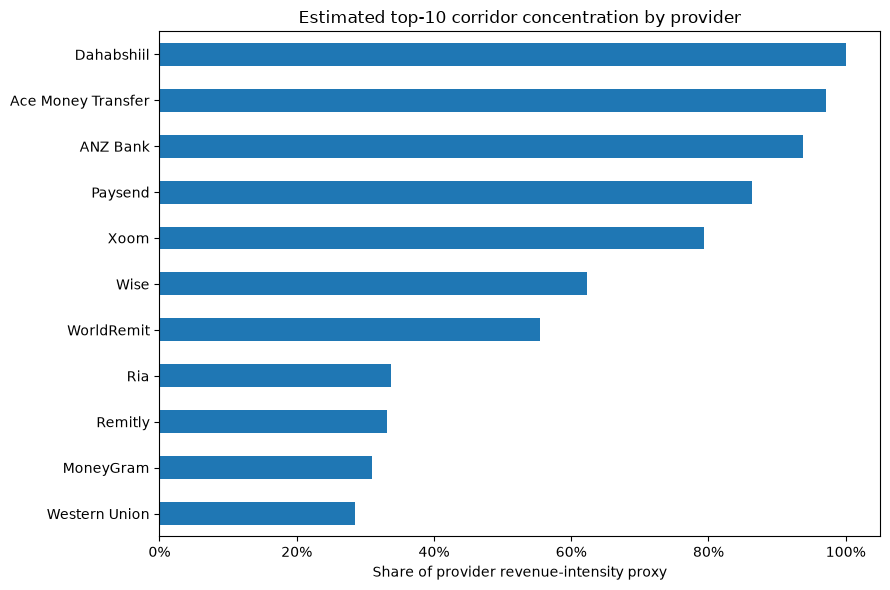

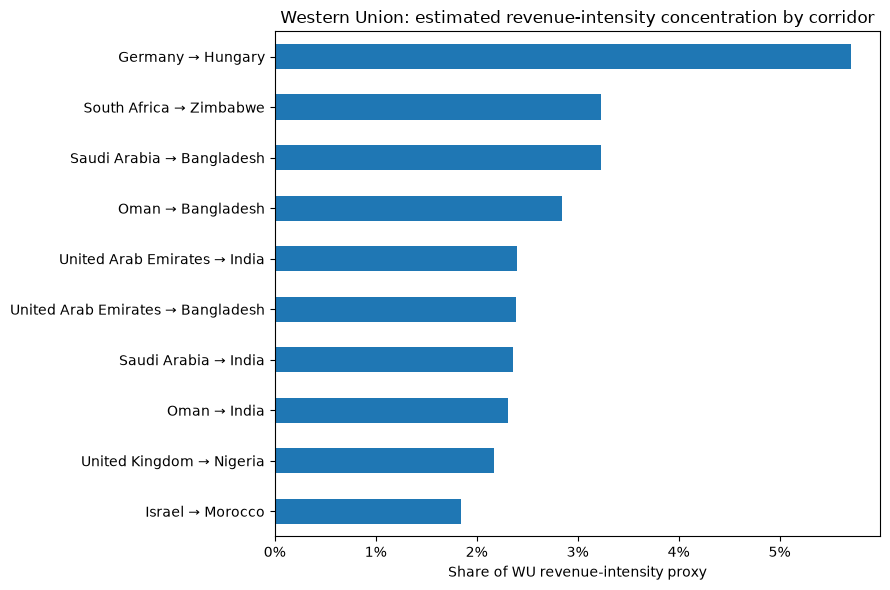

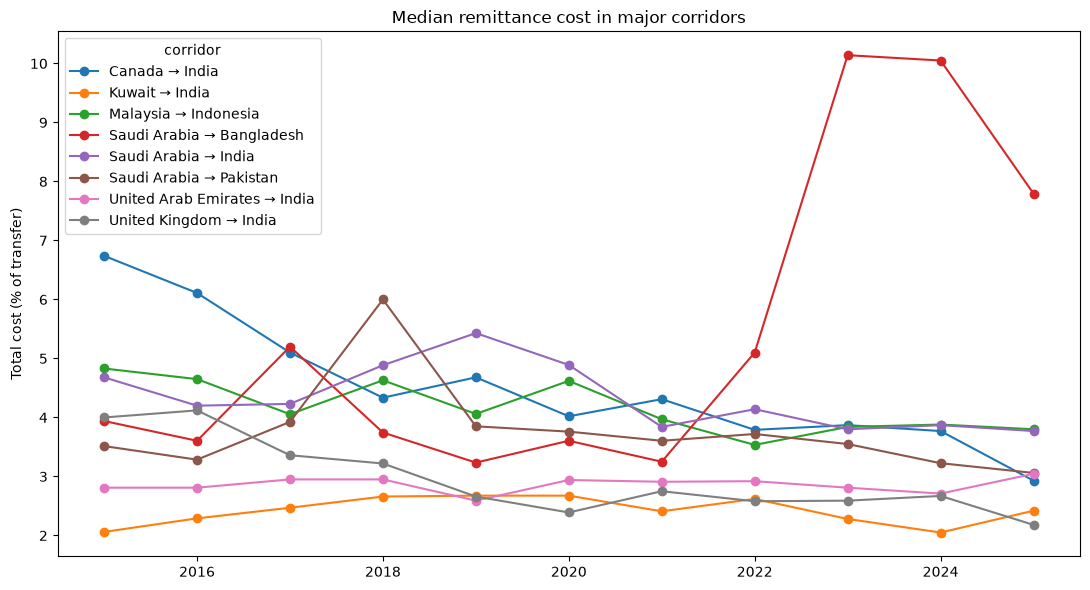

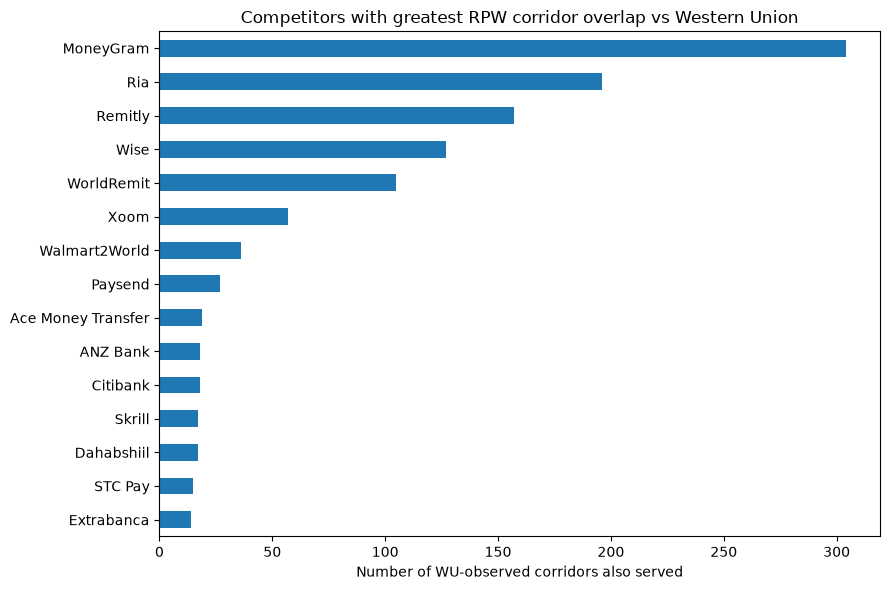

Saved figures to C:\Users\micha\OneDrive\Documents\ChatGPT\alphasensecheck\python_analysis\outputs\colab\local_outputs\wu_writeup_figures


In [34]:
#@title 32. Writeup charts — concentration, top corridors, pricing trend, competitor overlap
import matplotlib.pyplot as plt
from pathlib import Path
FIGDIR=Path.cwd() / 'local_outputs' / 'wu_writeup_figures'; FIGDIR.mkdir(exist_ok=True)

# Figure 1: Top-10 corridor concentration by major provider
plot=PROVIDER_CONCENTRATION_PRIMARY[PROVIDER_CONCENTRATION_PRIMARY.provider_canon.isin(majors)].sort_values("top10_share")
ax=plot.plot.barh(x="provider_canon",y="top10_share",legend=False,figsize=(9,6),title="Estimated top-10 corridor concentration by provider")
ax.set_xlabel("Share of provider revenue-intensity proxy"); ax.set_ylabel("");
ax.xaxis.set_major_formatter(lambda x,pos:f"{x:.0%}")
plt.tight_layout(); plt.savefig(FIGDIR/'01_provider_top10_concentration.png',dpi=180,bbox_inches='tight'); plt.show()

# Figure 2: WU top-10 corridors
wut=top_corridors("Western Union",n=10).sort_values("within_provider_share")
ax=wut.plot.barh(x="corridor",y="within_provider_share",legend=False,figsize=(9,6),title="Western Union: estimated revenue-intensity concentration by corridor")
ax.set_xlabel("Share of WU revenue-intensity proxy"); ax.set_ylabel(""); ax.xaxis.set_major_formatter(lambda x,pos:f"{x:.0%}")
plt.tight_layout(); plt.savefig(FIGDIR/'02_wu_top10_corridors.png',dpi=180,bbox_inches='tight'); plt.show()

# Figure 3: pricing trends for largest 8 RPW-covered corridors
show=TOP_FLOW_CORRIDORS[:8]
piv=CORRIDOR_PRICE_TREND[CORRIDOR_PRICE_TREND.corridor.isin(show)].pivot(index="year",columns="corridor",values="median_cost")
ax=piv.plot(figsize=(11,6),marker='o',title="Median remittance cost in major corridors")
ax.set_ylabel("Total cost (% of transfer)"); ax.set_xlabel("");
plt.tight_layout(); plt.savefig(FIGDIR/'03_major_corridor_pricing_trends.png',dpi=180,bbox_inches='tight'); plt.show()

# Figure 4: competitor overlap with WU
ov=WU_COMPETITOR_OVERLAP.query("provider_canon!='Western Union'").head(15).sort_values("overlap_with_wu")
ax=ov.plot.barh(x="provider_canon",y="overlap_with_wu",legend=False,figsize=(9,6),title="Competitors with greatest RPW corridor overlap vs Western Union")
ax.set_xlabel("Number of WU-observed corridors also served"); ax.set_ylabel("");
plt.tight_layout(); plt.savefig(FIGDIR/'04_wu_competitor_overlap.png',dpi=180,bbox_inches='tight'); plt.show()

print('Saved figures to',FIGDIR)


In [35]:
#@title 33. Writeup-ready summary tables
# Table A: WU concentration summary
wuconc=PROVIDER_CONCENTRATION_PRIMARY.query("provider_canon=='Western Union'").copy()
WRITEUP_WU_CONCENTRATION=wuconc[["provider_canon","corridors","top1_share","top5_share","top10_share","top20_share","hhi_10000","effective_corridors_1_hhi","gini"]]

# Table B: Provider comparison
WRITEUP_PROVIDER_COMPARISON=(PROVIDER_CONCENTRATION_PRIMARY
    .merge(PROVIDER_BREADTH,on="provider_canon",how="left",suffixes=("","_breadth"))
    .merge(PROVIDER_PRICING[["provider_canon","median_total_cost","median_cost_vs_corridor_pp","pct_corridors_below_median"]],on="provider_canon",how="left")
    .sort_values("corridors_breadth",ascending=False)
    .head(20))

# Table C: WU top 10 corridors
WRITEUP_WU_TOP10=top_corridors("Western Union",n=10).copy()

# Table D: WU top sending/receiving countries
WRITEUP_WU_COUNTRIES=WU_TOP_COUNTRIES.copy()

# Table E: major-corridor 10y pricing change
WRITEUP_CORRIDOR_PRICING=CORRIDOR_PRICE_CHANGE.copy()

for name,obj in [("WU concentration",WRITEUP_WU_CONCENTRATION),("Provider comparison",WRITEUP_PROVIDER_COMPARISON),
                 ("WU top 10 corridors",WRITEUP_WU_TOP10),("WU countries",WRITEUP_WU_COUNTRIES),("Corridor pricing",WRITEUP_CORRIDOR_PRICING)]:
    print("\n",name); display(obj)



 WU concentration


,provider_canon,corridors,top1_share,top5_share,top10_share,top20_share,hhi_10000,effective_corridors_1_hhi,gini
247,Western Union,233.0,0.057096,0.17412,0.28486,0.423664,142.073042,70.38633,0.616404



 Provider comparison


,provider_canon,corridors,top1_share,top5_share,top10_share,top20_share,hhi_0_1,hhi_10000,effective_corridors_1_hhi,gini,entropy,effective_corridors_entropy,metric,corridors_breadth,send_countries,receive_countries,quotes,median_total_cost,median_cost_vs_corridor_pp,pct_corridors_below_median
83,Western Union,233.0,0.057096,0.174120,0.284860,0.423664,0.014207,142.073042,70.386330,0.616404,4.745078,115.016775,revenue_intensity_proxy,336,43,94,1144,4.4900,0.0450,0.363095
82,MoneyGram,211.0,0.063532,0.197203,0.309428,0.459238,0.016404,164.042291,60.959890,0.624675,4.620877,101.583048,revenue_intensity_proxy,306,42,88,785,3.9050,0.0000,0.483660
80,Ria,130.0,0.062304,0.216532,0.337381,0.503562,0.019276,192.762954,51.877188,0.552240,4.326017,75.642416,revenue_intensity_proxy,197,18,77,510,4.3600,0.0000,0.456853
81,Remitly,105.0,0.064020,0.209374,0.331055,0.533456,0.020630,206.301586,48.472725,0.504216,4.213642,67.602269,revenue_intensity_proxy,159,16,67,734,3.4750,-0.1600,0.540881
78,Wise,88.0,0.222928,0.475475,0.623744,0.748472,0.074303,743.034521,13.458325,0.688183,3.423548,30.678062,revenue_intensity_proxy,127,23,30,267,2.6700,-0.5400,0.692913
79,WorldRemit,81.0,0.103435,0.361777,0.554756,0.722212,0.040318,403.176537,24.803031,0.621791,3.662600,38.962510,revenue_intensity_proxy,108,18,35,358,2.9800,-0.7150,0.666667
77,Xoom,23.0,0.189445,0.564766,0.793265,0.987474,0.091328,913.283175,10.949506,0.499196,2.704517,14.947097,revenue_intensity_proxy,58,7,40,178,5.9350,1.3325,0.155172
76,Paysend,20.0,0.218678,0.676428,0.863508,1.000000,0.112823,1128.232496,8.863421,0.543749,2.488423,12.042272,revenue_intensity_proxy,29,11,22,66,2.1200,-1.0100,0.793103
60,Dahabshiil,5.0,0.700718,1.000000,1.000000,1.000000,0.538242,5382.418258,1.857901,0.634090,0.839614,2.315472,revenue_intensity_proxy,19,6,12,21,6.0000,1.4200,0.368421
71,Ace Money Transfer,14.0,0.361463,0.813225,0.971024,1.000000,0.194076,1940.757517,5.152627,0.603650,1.989876,7.314626,revenue_intensity_proxy,19,6,16,54,2.0100,-1.0400,0.736842



 WU top 10 corridors


,provider_canon,corridor,flow_usd,quote_share,providers,median_cost,cost_vs_corridor_median_pp,revenue_intensity_proxy,within_provider_share,cum_share
2032,Western Union,Germany → Hungary,2.454011e+09,0.388889,5,13.300,7.230,1.269269e+08,0.057096,0.057096
2173,Western Union,South Africa → Zimbabwe,2.259411e+09,0.100000,12,31.810,21.530,7.187185e+07,0.032330,0.089426
2136,Western Union,Saudi Arabia → Bangladesh,7.792656e+09,0.111111,7,8.290,0.000,7.177902e+07,0.032289,0.121715
2115,Western Union,Oman → Bangladesh,2.305604e+09,0.333333,7,8.220,0.000,6.317355e+07,0.028417,0.150132
2208,Western Union,United Arab Emirates → India,2.633454e+10,0.083333,12,2.430,-0.615,5.332745e+07,0.023988,0.174120
2206,Western Union,United Arab Emirates → Bangladesh,3.524606e+09,0.222222,7,6.785,-0.365,5.314323e+07,0.023906,0.198026
2139,Western Union,Saudi Arabia → India,1.521617e+10,0.083333,8,4.140,0.585,5.249579e+07,0.023614,0.221640
2116,Western Union,Oman → India,5.977113e+09,0.272727,8,3.150,0.000,5.134883e+07,0.023098,0.244739
2234,Western Union,United Kingdom → Nigeria,4.326655e+09,0.290323,8,3.840,2.830,4.823522e+07,0.021698,0.266436
2048,Western Union,Israel → Morocco,7.236221e+08,0.333333,3,16.980,3.510,4.095701e+07,0.018424,0.284860



 WU countries


,country,revenue_intensity_proxy,share,side,rank
0,Germany,2.851988e+08,0.128292,send,1
1,Saudi Arabia,2.041664e+08,0.091841,send,2
2,United Arab Emirates,1.815063e+08,0.081647,send,3
3,Spain,1.610737e+08,0.072456,send,4
4,United Kingdom,1.609068e+08,0.072381,send,5
5,Canada,1.499456e+08,0.067450,send,6
6,France,1.394745e+08,0.062740,send,7
7,Oman,1.301233e+08,0.058534,send,8
8,South Africa,1.243536e+08,0.055938,send,9
9,Qatar,1.049771e+08,0.047222,send,10



 Corridor pricing


,corridor,start_year,end_year,start_cost,end_cost,cost_change_pp,annual_change_pp,start_providers,end_providers,provider_change
18,United Kingdom → Nigeria,2015,2025,7.990,1.945,-6.045,-0.604500,13,9,-4
1,Canada → India,2015,2025,6.740,2.930,-3.810,-0.381000,14,13,-1
0,Australia → India,2015,2025,5.700,3.040,-2.660,-0.266000,27,22,-5
3,France → Morocco,2015,2025,5.980,3.670,-2.310,-0.231000,15,18,3
17,United Kingdom → India,2015,2025,4.000,2.180,-1.820,-0.182000,16,13,-3
13,Spain → Morocco,2015,2025,5.530,3.885,-1.645,-0.164500,12,9,-3
12,Spain → Colombia,2015,2025,6.100,4.470,-1.630,-0.163000,11,10,-1
11,Saudi Arabia → Philippines,2015,2025,4.550,2.970,-1.580,-0.158000,7,6,-1
7,Qatar → India,2015,2025,4.495,2.990,-1.505,-0.150500,10,5,-5
19,United Kingdom → Pakistan,2015,2025,3.415,1.955,-1.460,-0.146000,8,8,0


In [36]:
#@title 34. Optional WU calibration to reported CMT revenue / principal
# Enter reported values if desired. The concentration shares do not depend on these values.
WU_REPORTED_CMT_REVENUE = 3.507e9   # 2025 CMT revenue; edit if using another period
WU_REPORTED_PRINCIPAL = 107.4e9     # 2025 cross-border principal; edit if using another period

wu_proxy=PROVIDER_FLOW_2024[(PROVIDER_FLOW_2024.provider_canon=="Western Union") & PROVIDER_FLOW_2024.revenue_intensity_proxy.notna()].copy()
if wu_proxy.revenue_intensity_proxy.sum()>0:
    wu_proxy["revenue_proxy_share"] = wu_proxy.revenue_intensity_proxy / wu_proxy.revenue_intensity_proxy.sum()
    wu_proxy["calibrated_cmt_revenue"] = wu_proxy.revenue_proxy_share * WU_REPORTED_CMT_REVENUE
    wu_proxy["calibrated_principal"] = wu_proxy.revenue_proxy_share * WU_REPORTED_PRINCIPAL
    WU_CALIBRATED_CORRIDOR_REVENUE = wu_proxy.sort_values("calibrated_cmt_revenue",ascending=False)
    display(WU_CALIBRATED_CORRIDOR_REVENUE[["corridor","flow_usd","quote_share","median_cost","revenue_proxy_share","calibrated_cmt_revenue","calibrated_principal"]].head(25).style.format({
        "flow_usd":"${:,.0f}","quote_share":"{:.1%}","median_cost":"{:.2f}%","revenue_proxy_share":"{:.1%}","calibrated_cmt_revenue":"${:,.0f}","calibrated_principal":"${:,.0f}"
    }))
    print("WARNING: calibrated dollars are model allocations, not company-disclosed corridor revenue/principal.")


,corridor,flow_usd,quote_share,median_cost,revenue_proxy_share,calibrated_cmt_revenue,calibrated_principal
2032,Germany → Hungary,"$2,454,010,999",38.9%,13.30%,5.7%,"$200,234,980","$6,132,089,206"
2173,South Africa → Zimbabwe,"$2,259,410,507",10.0%,31.81%,3.2%,"$113,382,253","$3,472,270,866"
2136,Saudi Arabia → Bangladesh,"$7,792,655,611",11.1%,8.29%,3.2%,"$113,235,805","$3,467,785,991"
2115,Oman → Bangladesh,"$2,305,604,044",33.3%,8.22%,2.8%,"$99,660,154","$3,052,038,947"
2208,United Arab Emirates → India,"$26,334,542,340",8.3%,2.43%,2.4%,"$84,127,323","$2,576,354,295"
2206,United Arab Emirates → Bangladesh,"$3,524,606,413",22.2%,6.79%,2.4%,"$83,836,711","$2,567,454,457"
2139,Saudi Arabia → India,"$15,216,172,432",8.3%,4.14%,2.4%,"$82,815,339","$2,536,175,480"
2116,Oman → India,"$5,977,112,744",27.3%,3.15%,2.3%,"$81,005,935","$2,480,763,449"
2234,United Kingdom → Nigeria,"$4,326,654,913",29.0%,3.84%,2.2%,"$76,094,027","$2,330,338,881"
2048,Israel → Morocco,"$723,622,134",33.3%,16.98%,1.8%,"$64,612,202","$1,978,714,139"


In [37]:
#@title 35. Export extended analysis workbook + figure manifest
from pathlib import Path
OUT_EXT=Path.cwd() / 'local_outputs' / 'WU_RPW_Extended_Analysis.xlsx'
OUT_EXT.parent.mkdir(parents=True, exist_ok=True)
with pd.ExcelWriter(OUT_EXT,engine='openpyxl') as xw:
    PROVIDER_CORRIDOR_LATEST.to_excel(xw, sheet_name='provider_corridor_latest', index=False)
    PROVIDER_FLOW_2024.to_excel(xw, sheet_name='provider_flow_2024', index=False)
    PROVIDER_FLOW_COVERAGE.to_excel(xw, sheet_name='flow_coverage', index=False)
    PROVIDER_CONCENTRATION.to_excel(xw, sheet_name='provider_concentration', index=False)
    TOP10_PROVIDER_CORRIDORS.to_excel(xw, sheet_name='provider_top10_corridors', index=False)
    PROVIDER_COUNTRY_CONCENTRATION.to_excel(xw, sheet_name='country_concentration', index=False)
    WU_TOP_COUNTRIES.to_excel(xw, sheet_name='wu_top_countries', index=False)
    WU_CONCENTRATION_SENSITIVITY.to_excel(xw, sheet_name='wu_sensitivity', index=False)
    CORRIDOR_COMPETITION.to_excel(xw, sheet_name='corridor_competition', index=False)
    PROVIDER_PRICING.to_excel(xw, sheet_name='provider_pricing', index=False)
    CORRIDOR_PRICE_TREND.to_excel(xw, sheet_name='corridor_price_trend', index=False)
    CORRIDOR_PRICE_CHANGE.to_excel(xw, sheet_name='corridor_price_change', index=False)
    PROVIDER_CHANNEL.to_excel(xw, sheet_name='provider_channel_mix', index=False)
    PROVIDER_BREADTH.to_excel(xw, sheet_name='provider_breadth', index=False)
    WU_COMPETITOR_OVERLAP.to_excel(xw, sheet_name='wu_competitor_overlap', index=False)
    WRITEUP_WU_CONCENTRATION.to_excel(xw, sheet_name='WRITEUP_wu_concentration', index=False)
    WRITEUP_PROVIDER_COMPARISON.to_excel(xw, sheet_name='WRITEUP_provider_compare', index=False)
    WRITEUP_WU_TOP10.to_excel(xw, sheet_name='WRITEUP_wu_top10', index=False)
    WRITEUP_WU_COUNTRIES.to_excel(xw, sheet_name='WRITEUP_wu_countries', index=False)
    WRITEUP_CORRIDOR_PRICING.to_excel(xw, sheet_name='WRITEUP_corridor_pricing', index=False)
    if 'WU_CALIBRATED_CORRIDOR_REVENUE' in globals():
        WU_CALIBRATED_CORRIDOR_REVENUE.to_excel(xw, sheet_name='wu_calibrated_model', index=False)
print('Saved:',OUT_EXT)
print('Figures:', sorted(str(x) for x in FIGDIR.glob('*.png')) if 'FIGDIR' in globals() else 'Run chart cell first')


Saved: C:\Users\micha\OneDrive\Documents\ChatGPT\alphasensecheck\python_analysis\outputs\colab\local_outputs\WU_RPW_Extended_Analysis.xlsx
Figures: ['C:\\Users\\micha\\OneDrive\\Documents\\ChatGPT\\alphasensecheck\\python_analysis\\outputs\\colab\\local_outputs\\wu_writeup_figures\\01_provider_top10_concentration.png', 'C:\\Users\\micha\\OneDrive\\Documents\\ChatGPT\\alphasensecheck\\python_analysis\\outputs\\colab\\local_outputs\\wu_writeup_figures\\02_wu_top10_corridors.png', 'C:\\Users\\micha\\OneDrive\\Documents\\ChatGPT\\alphasensecheck\\python_analysis\\outputs\\colab\\local_outputs\\wu_writeup_figures\\03_major_corridor_pricing_trends.png', 'C:\\Users\\micha\\OneDrive\\Documents\\ChatGPT\\alphasensecheck\\python_analysis\\outputs\\colab\\local_outputs\\wu_writeup_figures\\04_wu_competitor_overlap.png']


### Interpretation guardrails for the writeup

- RPW is a **pricing/availability sample**, not transaction-level market-share data. Do not call quote share actual market share.
- The 2024 bilateral matrix in this notebook is modeled; label it accordingly and use observed central-bank bilateral data where available as a replacement/validation layer.
- The `revenue_intensity_proxy` is best used for **relative concentration within a provider**. It should not be described as reported revenue.
- WU-calibrated corridor dollars are a scenario allocation to reported CMT totals. Present a range across sensitivity cases rather than a single precise number.
- For Question 10, the most defensible outputs are the sensitivity range for WU top-10 corridor concentration, top-10 sender/receiver-country concentration, and comparisons against large competitors.
- For Question 8, show the 10-year cost paths of major corridors together with provider-count changes; these give a quantitative competition/pricing narrative.
- For Question 2, use provider footprint share, flow-weighted footprint proxy, and reported company principal/revenue market share as **separate definitions** rather than blending them.
